In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/deep-daiv-loan-default-prediction/loan_train.csv
/kaggle/input/deep-daiv-loan-default-prediction/loan_sample_submission.csv
/kaggle/input/deep-daiv-loan-default-prediction/loan_test.csv


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import warnings
pd.options.display.max_columns=None

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [3]:
test = pd.read_csv('/kaggle/input/deep-daiv-loan-default-prediction/loan_test.csv')
test.head()

,Unnamed: 0,ID,Loan Amount,Funded Amount,Funded Amount Investor,Term,Batch Enrolled,Interest Rate,Grade,Sub Grade,Employment Duration,Home Ownership,Verification Status,Payment Plan,Loan Title,Debit to Income,Delinquency - two years,Inquires - six months,Open Account,Public Record,Revolving Balance,Revolving Utilities,Total Accounts,Initial List Status,Total Received Interest,Total Received Late Fee,Recoveries,Collection Recovery Fee,Collection 12 months Medical,Application Type,Last week Pay,Accounts Delinquent,Total Collection Amount,Total Current Balance,Total Revolving Credit Limit
0,36091,4325622,13563,21413,12463.155600,59,BAT2803411,14.751364,D,A5,MORTGAGE,63440.11038,Not Verified,n,Debt consolidation,34.375557,0,0,11,0,7839,37.402208,31,w,1151.185980,0.030013,4.269588,0.409783,0,INDIVIDUAL,68,0,7,188728,21518
1,54766,7229365,33439,16621,6210.318604,59,BAT2136391,9.387852,B,B5,OWN,49794.87694,Source Verified,n,Debt consolidation,9.310572,0,0,12,0,2020,44.729742,12,f,1905.986273,0.001364,0.620891,1.520634,0,INDIVIDUAL,36,0,33,63335,17216
2,14596,70628847,17032,11506,21429.794360,58,BAT2575549,8.795768,F,D4,MORTGAGE,32570.47932,Not Verified,n,Credit card refinancing,14.837017,0,0,13,0,6517,92.173043,9,w,294.578391,0.093213,5.930913,0.646068,0,INDIVIDUAL,65,0,30,267607,8264
3,58610,6334325,19569,7733,19953.814820,59,BAT4722912,7.020324,A,E3,MORTGAGE,112926.42860,Source Verified,n,Other,37.344394,2,0,21,1,1551,57.611870,12,f,2355.479720,0.082692,2.144186,0.292054,0,INDIVIDUAL,127,0,50,364029,12025
4,49849,14750245,30431,8448,12166.495990,59,BAT3873588,12.673065,B,E1,MORTGAGE,30775.35291,Source Verified,n,Debt consolidation,17.125386,0,1,14,1,3130,54.229572,23,w,1040.150183,0.040332,6.463596,1.214837,0,INDIVIDUAL,160,0,29,308349,25981


In [4]:
train = pd.read_csv('/kaggle/input/deep-daiv-loan-default-prediction/loan_train.csv')
train.head()

,Unnamed: 0,ID,Loan Amount,Funded Amount,Funded Amount Investor,Term,Batch Enrolled,Interest Rate,Grade,Sub Grade,Employment Duration,Home Ownership,Verification Status,Payment Plan,Loan Title,Debit to Income,Delinquency - two years,Inquires - six months,Open Account,Public Record,Revolving Balance,Revolving Utilities,Total Accounts,Initial List Status,Total Received Interest,Total Received Late Fee,Recoveries,Collection Recovery Fee,Collection 12 months Medical,Application Type,Last week Pay,Accounts Delinquent,Total Collection Amount,Total Current Balance,Total Revolving Credit Limit,Loan Status
0,58459,57890399,14986,6848,14215.834900,58,BAT1766061,17.841656,A,G5,MORTGAGE,66291.22833,Source Verified,n,Credit card refinancing,22.628291,0,0,16,0,8993,34.734212,16,f,4694.025115,0.000056,5.460927,0.692790,0,JOINT,159,0,41,16762,6137,0
1,9781,14627222,25795,5588,10972.781160,58,BAT4694572,11.655297,B,C1,MORTGAGE,78002.00947,Source Verified,n,Debt consolidation,12.321649,1,0,29,0,18158,87.503244,10,w,5224.407117,0.056749,1.390781,1.415970,0,INDIVIDUAL,141,0,21,411722,8417,0
2,50851,63209318,4200,16786,7370.911374,59,BAT1104812,10.499741,B,B4,RENT,71538.83031,Source Verified,n,Credit card refinancing,32.920842,1,0,6,0,2219,62.248790,10,f,476.065484,0.011840,4.888484,1.410109,0,INDIVIDUAL,152,0,20,70438,6932,0
3,61967,5295524,17148,21912,4840.020550,59,BAT4722912,14.274406,E,B3,OWN,49315.79444,Source Verified,n,Credit card refinance,25.514694,0,3,17,0,17976,38.034926,22,f,223.889079,20.264162,0.842342,0.693088,0,INDIVIDUAL,145,0,17,414692,19552,0
4,8941,27540920,20848,11668,13408.689070,59,BAT1104812,10.343987,C,D4,MORTGAGE,45261.55641,Verified,n,Credit card refinancing,13.528166,0,0,9,0,7650,52.413628,10,w,642.600925,0.003445,2.834972,0.667659,0,INDIVIDUAL,106,0,49,49760,34135,0


In [5]:
combined = pd.concat([train,test])
combined.head()

,Unnamed: 0,ID,Loan Amount,Funded Amount,Funded Amount Investor,Term,Batch Enrolled,Interest Rate,Grade,Sub Grade,Employment Duration,Home Ownership,Verification Status,Payment Plan,Loan Title,Debit to Income,Delinquency - two years,Inquires - six months,Open Account,Public Record,Revolving Balance,Revolving Utilities,Total Accounts,Initial List Status,Total Received Interest,Total Received Late Fee,Recoveries,Collection Recovery Fee,Collection 12 months Medical,Application Type,Last week Pay,Accounts Delinquent,Total Collection Amount,Total Current Balance,Total Revolving Credit Limit,Loan Status
0,58459,57890399,14986,6848,14215.834900,58,BAT1766061,17.841656,A,G5,MORTGAGE,66291.22833,Source Verified,n,Credit card refinancing,22.628291,0,0,16,0,8993,34.734212,16,f,4694.025115,0.000056,5.460927,0.692790,0,JOINT,159,0,41,16762,6137,0.0
1,9781,14627222,25795,5588,10972.781160,58,BAT4694572,11.655297,B,C1,MORTGAGE,78002.00947,Source Verified,n,Debt consolidation,12.321649,1,0,29,0,18158,87.503244,10,w,5224.407117,0.056749,1.390781,1.415970,0,INDIVIDUAL,141,0,21,411722,8417,0.0
2,50851,63209318,4200,16786,7370.911374,59,BAT1104812,10.499741,B,B4,RENT,71538.83031,Source Verified,n,Credit card refinancing,32.920842,1,0,6,0,2219,62.248790,10,f,476.065484,0.011840,4.888484,1.410109,0,INDIVIDUAL,152,0,20,70438,6932,0.0
3,61967,5295524,17148,21912,4840.020550,59,BAT4722912,14.274406,E,B3,OWN,49315.79444,Source Verified,n,Credit card refinance,25.514694,0,3,17,0,17976,38.034926,22,f,223.889079,20.264162,0.842342,0.693088,0,INDIVIDUAL,145,0,17,414692,19552,0.0
4,8941,27540920,20848,11668,13408.689070,59,BAT1104812,10.343987,C,D4,MORTGAGE,45261.55641,Verified,n,Credit card refinancing,13.528166,0,0,9,0,7650,52.413628,10,w,642.600925,0.003445,2.834972,0.667659,0,INDIVIDUAL,106,0,49,49760,34135,0.0


In [6]:
combined.infer_objects()

,Unnamed: 0,ID,Loan Amount,Funded Amount,Funded Amount Investor,Term,Batch Enrolled,Interest Rate,Grade,Sub Grade,Employment Duration,Home Ownership,Verification Status,Payment Plan,Loan Title,Debit to Income,Delinquency - two years,Inquires - six months,Open Account,Public Record,Revolving Balance,Revolving Utilities,Total Accounts,Initial List Status,Total Received Interest,Total Received Late Fee,Recoveries,Collection Recovery Fee,Collection 12 months Medical,Application Type,Last week Pay,Accounts Delinquent,Total Collection Amount,Total Current Balance,Total Revolving Credit Limit,Loan Status
0,58459,57890399,14986,6848,14215.834900,58,BAT1766061,17.841656,A,G5,MORTGAGE,66291.22833,Source Verified,n,Credit card refinancing,22.628291,0,0,16,0,8993,34.734212,16,f,4694.025115,0.000056,5.460927,0.692790,0,JOINT,159,0,41,16762,6137,0.0
1,9781,14627222,25795,5588,10972.781160,58,BAT4694572,11.655297,B,C1,MORTGAGE,78002.00947,Source Verified,n,Debt consolidation,12.321649,1,0,29,0,18158,87.503244,10,w,5224.407117,0.056749,1.390781,1.415970,0,INDIVIDUAL,141,0,21,411722,8417,0.0
2,50851,63209318,4200,16786,7370.911374,59,BAT1104812,10.499741,B,B4,RENT,71538.83031,Source Verified,n,Credit card refinancing,32.920842,1,0,6,0,2219,62.248790,10,f,476.065484,0.011840,4.888484,1.410109,0,INDIVIDUAL,152,0,20,70438,6932,0.0
3,61967,5295524,17148,21912,4840.020550,59,BAT4722912,14.274406,E,B3,OWN,49315.79444,Source Verified,n,Credit card refinance,25.514694,0,3,17,0,17976,38.034926,22,f,223.889079,20.264162,0.842342,0.693088,0,INDIVIDUAL,145,0,17,414692,19552,0.0
4,8941,27540920,20848,11668,13408.689070,59,BAT1104812,10.343987,C,D4,MORTGAGE,45261.55641,Verified,n,Credit card refinancing,13.528166,0,0,9,0,7650,52.413628,10,w,642.600925,0.003445,2.834972,0.667659,0,INDIVIDUAL,106,0,49,49760,34135,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20234,19483,4606626,10002,19217,19078.499460,59,BAT3865626,12.436152,E,B1,RENT,64285.30754,Verified,n,Credit card refinancing,26.421800,0,0,16,1,6428,86.260689,5,w,209.939457,0.085483,4.750810,0.502660,0,INDIVIDUAL,6,0,55,332160,6102,NaN
20235,16574,1758863,17285,26107,14283.046960,59,BAT2522922,5.435835,B,A3,RENT,108273.03040,Source Verified,n,Credit card refinancing,18.456630,0,0,12,0,7715,91.759348,33,f,1068.981029,0.032857,8.522830,0.794287,0,INDIVIDUAL,129,0,5,216475,37493,NaN
20236,55158,8612095,21551,6142,22517.494520,59,BAT2575549,17.257780,C,G5,MORTGAGE,64378.60665,Not Verified,n,Debt Consolidation,25.513071,1,0,14,0,4072,71.189991,14,f,1352.429428,0.047721,5.577969,0.128355,0,INDIVIDUAL,104,0,41,410314,13185,NaN
20237,33780,63125929,14629,12954,6534.523479,59,BAT2803411,10.652493,C,B2,MORTGAGE,122372.73350,Source Verified,n,Credit card refinancing,19.204373,0,0,15,0,323,59.874045,10,w,2780.000042,0.138411,4.155788,1.414116,0,INDIVIDUAL,95,0,49,441772,31040,NaN


In [7]:
combined.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 67463 entries, 0 to 20238
Data columns (total 36 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Unnamed: 0                    67463 non-null  int64  
 1   ID                            67463 non-null  int64  
 2   Loan Amount                   67463 non-null  int64  
 3   Funded Amount                 67463 non-null  int64  
 4   Funded Amount Investor        67463 non-null  float64
 5   Term                          67463 non-null  int64  
 6   Batch Enrolled                67463 non-null  object 
 7   Interest Rate                 67463 non-null  float64
 8   Grade                         67463 non-null  object 
 9   Sub Grade                     67463 non-null  object 
 10  Employment Duration           67463 non-null  object 
 11  Home Ownership                67463 non-null  float64
 12  Verification Status           67463 non-null  object 
 13  P

In [8]:
combined.dtypes

Unnamed: 0                        int64
ID                                int64
Loan Amount                       int64
Funded Amount                     int64
Funded Amount Investor          float64
Term                              int64
Batch Enrolled                   object
Interest Rate                   float64
Grade                            object
Sub Grade                        object
Employment Duration              object
Home Ownership                  float64
Verification Status              object
Payment Plan                     object
Loan Title                       object
Debit to Income                 float64
Delinquency - two years           int64
Inquires - six months             int64
Open Account                      int64
Public Record                     int64
Revolving Balance                 int64
Revolving Utilities             float64
Total Accounts                    int64
Initial List Status              object
Total Received Interest         float64


In [9]:
combined.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,67463.0,3.373100e+04,1.947503e+04,0.000000e+00,1.686550e+04,3.373100e+04,5.059650e+04,6.746200e+04
ID,67463.0,2.562761e+07,2.109155e+07,1.297933e+06,6.570288e+06,1.791565e+07,4.271521e+07,7.224578e+07
Loan Amount,67463.0,1.684890e+04,8.367866e+03,1.014000e+03,1.001200e+04,1.607300e+04,2.210600e+04,3.500000e+04
Funded Amount,67463.0,1.577060e+04,8.150993e+03,1.014000e+03,9.266500e+03,1.304200e+04,2.179300e+04,3.499900e+04
Funded Amount Investor,67463.0,1.462180e+04,6.785345e+03,1.114590e+03,9.831685e+03,1.279368e+04,1.780759e+04,3.499975e+04
Term,67463.0,5.817381e+01,3.327441e+00,3.600000e+01,5.800000e+01,5.900000e+01,5.900000e+01,5.900000e+01
Interest Rate,67463.0,1.184626e+01,3.718629e+00,5.320006e+00,9.297147e+00,1.137770e+01,1.419353e+01,2.718235e+01
Home Ownership,67463.0,8.054150e+04,4.502912e+04,1.457354e+04,5.168984e+04,6.933583e+04,9.462332e+04,4.065615e+05
Debit to Income,67463.0,2.329924e+01,8.451824e+00,6.752991e-01,1.675642e+01,2.265666e+01,3.004840e+01,3.962986e+01
Delinquency - two years,67463.0,3.271275e-01,8.008884e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,8.000000e+00


In [10]:
# define the column your want to check for outliers
cols = ['Unnamed: 0','ID','Loan Amount','Funded Amount','Funded Amount Investor','Term','Interest Rate','Home Ownership','Debit to Income','Delinquency - two years','Inquires - six months','Open Account','Public Record','Revolving Balance','Revolving Utilities','Total Accounts','Total Received Interest','Total Received Late Fee','Recoveries','Collection Recovery Fee','Collection 12 months Medical','Last week Pay','Accounts Delinquent','Total Collection Amount','Total Current Balance','Total Revolving Credit Limit','Loan Status']

In [11]:
# Create an empty dictionary to store the results
outliers = {}

In [12]:
combined.corr()

/tmp/ipykernel_20/867344879.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  combined.corr()


,Unnamed: 0,ID,Loan Amount,Funded Amount,Funded Amount Investor,Term,Interest Rate,Home Ownership,Debit to Income,Delinquency - two years,Inquires - six months,Open Account,Public Record,Revolving Balance,Revolving Utilities,Total Accounts,Total Received Interest,Total Received Late Fee,Recoveries,Collection Recovery Fee,Collection 12 months Medical,Last week Pay,Accounts Delinquent,Total Collection Amount,Total Current Balance,Total Revolving Credit Limit,Loan Status
Unnamed: 0,1.000000,0.002179,0.002197,-0.003199,-0.002508,-0.000525,-0.005815,-0.000894,0.002352,-0.006529,0.001706,-0.007696,0.001695,-0.005472,-0.002223,0.002474,0.001186,0.001639,0.000387,-0.000580,0.005977,-0.000379,NaN,-0.000410,0.004158,0.002038,-0.009595
ID,0.002179,1.000000,-0.003480,-0.003302,0.002954,0.003226,0.004258,-0.004390,-0.010578,0.000568,-0.006628,-0.002781,0.009830,0.004315,0.000910,0.001518,-0.002938,0.006674,-0.001435,-0.001802,-0.002900,0.000907,NaN,0.003745,-0.003572,-0.005141,-0.000608
Loan Amount,0.002197,-0.003480,1.000000,-0.000551,0.002831,0.004277,-0.004888,0.016691,0.007959,-0.000469,0.008962,0.009088,-0.002542,-0.001738,0.014828,-0.002071,-0.001887,-0.000034,-0.001606,-0.002142,-0.002726,-0.002362,NaN,-0.004135,-0.008285,0.002289,-0.004368
Funded Amount,-0.003199,-0.003302,-0.000551,1.000000,0.010227,-0.001503,0.002310,-0.003518,0.002347,0.011313,-0.001587,0.005755,0.003750,-0.004485,0.004460,0.008298,0.002759,0.001542,0.000462,0.000175,0.001071,-0.003476,NaN,-0.002821,-0.001499,0.006145,0.001647
Funded Amount Investor,-0.002508,0.002954,0.002831,0.010227,1.000000,-0.008943,-0.001917,0.001339,0.000112,0.001925,-0.003073,-0.007850,0.005002,-0.009102,-0.003027,0.003191,0.001432,-0.000232,0.000966,-0.007272,0.001814,0.004248,NaN,0.006862,0.003283,0.005669,0.005980
Term,-0.000525,0.003226,0.004277,-0.001503,-0.008943,1.000000,-0.012688,-0.021813,0.001026,-0.004494,-0.005272,0.021362,-0.002827,-0.002317,-0.010018,0.001204,0.008663,-0.000736,-0.003475,-0.001203,-0.003263,0.007035,NaN,0.000358,0.003361,-0.005068,-0.007789
Interest Rate,-0.005815,0.004258,-0.004888,0.002310,-0.001917,-0.012688,1.000000,0.005467,-0.011203,0.004045,0.009172,-0.003250,0.006979,0.018999,0.006089,0.006584,0.006998,0.003119,0.009348,0.001281,-0.009895,-0.012652,NaN,0.002771,-0.002567,0.016651,0.005342
Home Ownership,-0.000894,-0.004390,0.016691,-0.003518,0.001339,-0.021813,0.005467,1.000000,0.022781,-0.003793,0.005024,0.009080,0.005631,0.016783,-0.005556,0.021452,-0.010346,0.004011,0.004399,-0.003821,-0.002639,-0.004573,NaN,0.006314,0.007117,0.005008,0.007058
Debit to Income,0.002352,-0.010578,0.007959,0.002347,0.000112,0.001026,-0.011203,0.022781,1.000000,-0.004007,0.002246,0.001100,-0.007813,-0.011414,0.003691,-0.005683,0.006504,-0.010224,-0.009693,0.002200,-0.000716,0.008639,NaN,0.001555,-0.011582,-0.007236,-0.003041
Delinquency - two years,-0.006529,0.000568,-0.000469,0.011313,0.001925,-0.004494,0.004045,-0.003793,-0.004007,1.000000,0.014679,0.004904,0.006716,0.009394,0.002474,-0.003085,-0.004511,0.007943,0.017348,0.002707,0.003451,0.001160,NaN,0.005642,0.002602,0.009315,0.015893


In [13]:
combined.isnull().sum()/len(combined)*100

Unnamed: 0                       0.000000
ID                               0.000000
Loan Amount                      0.000000
Funded Amount                    0.000000
Funded Amount Investor           0.000000
Term                             0.000000
Batch Enrolled                   0.000000
Interest Rate                    0.000000
Grade                            0.000000
Sub Grade                        0.000000
Employment Duration              0.000000
Home Ownership                   0.000000
Verification Status              0.000000
Payment Plan                     0.000000
Loan Title                       0.000000
Debit to Income                  0.000000
Delinquency - two years          0.000000
Inquires - six months            0.000000
Open Account                     0.000000
Public Record                    0.000000
Revolving Balance                0.000000
Revolving Utilities              0.000000
Total Accounts                   0.000000
Initial List Status              0

In [14]:
combined.shape

(67463, 36)

<AxesSubplot: >

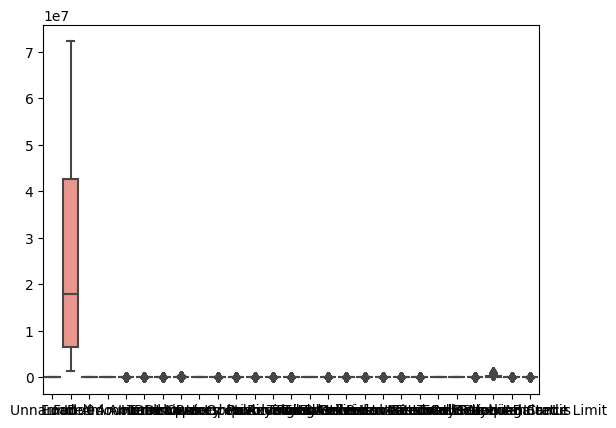

In [15]:
sns.boxplot(combined)

<AxesSubplot: >

/opt/conda/lib/python3.10/site-packages/IPython/core/events.py:89: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/opt/conda/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


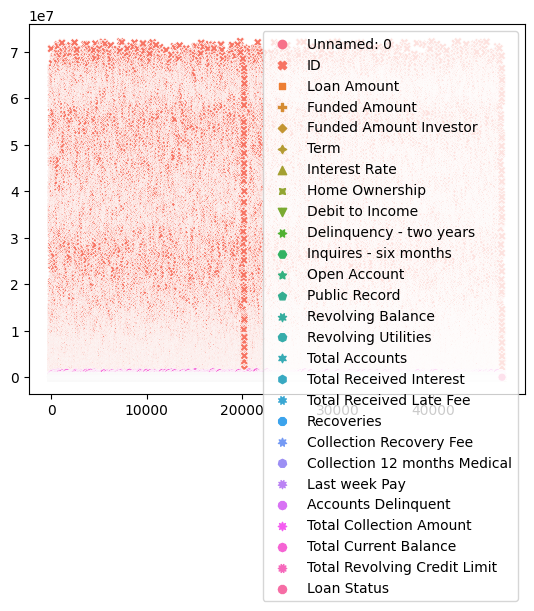

In [16]:
sns.scatterplot(combined)

/tmp/ipykernel_20/1658940522.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(combined.corr(),annot=True)


<AxesSubplot: >

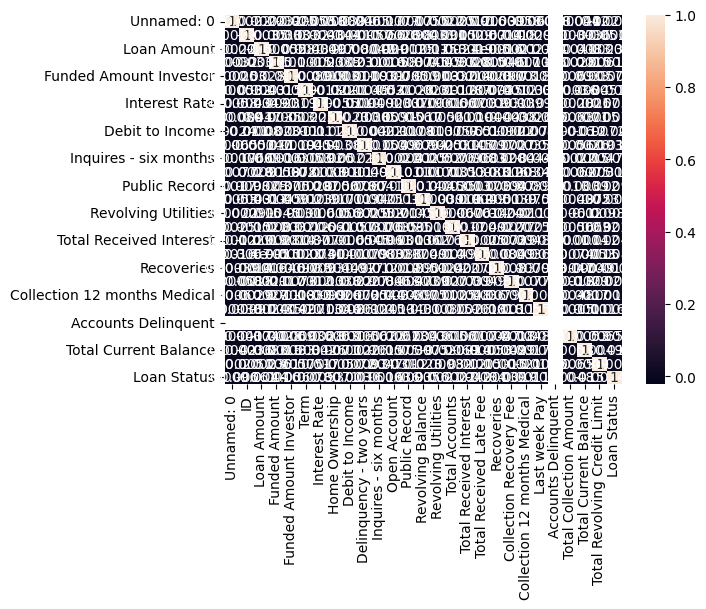

In [17]:
sns.heatmap(combined.corr(),annot=True)

In [18]:
Q1 = combined.quantile(0.25)
Q2 = combined.quantile(0.5)
Q3 = combined.quantile(0.75)
IQR=Q3-Q1
print(IQR)

Unnamed: 0                      3.373100e+04
ID                              3.614492e+07
Loan Amount                     1.209400e+04
Funded Amount                   1.252650e+04
Funded Amount Investor          7.975909e+03
Term                            1.000000e+00
Interest Rate                   4.896386e+00
Home Ownership                  4.293348e+04
Debit to Income                 1.329198e+01
Delinquency - two years         0.000000e+00
Inquires - six months           0.000000e+00
Open Account                    6.000000e+00
Public Record                   0.000000e+00
Revolving Balance               7.627500e+03
Revolving Utilities             3.051829e+01
Total Accounts                  1.000000e+01
Total Received Interest         2.086053e+03
Total Received Late Fee         5.077011e-02
Recoveries                      3.823909e+00
Collection Recovery Fee         5.943062e-01
Collection 12 months Medical    0.000000e+00
Last week Pay                   7.000000e+01
Accounts D

/tmp/ipykernel_20/2240195514.py:1: FutureWarning: The default value of numeric_only in DataFrame.quantile is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  Q1 = combined.quantile(0.25)
/tmp/ipykernel_20/2240195514.py:2: FutureWarning: The default value of numeric_only in DataFrame.quantile is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  Q2 = combined.quantile(0.5)
/tmp/ipykernel_20/2240195514.py:3: FutureWarning: The default value of numeric_only in DataFrame.quantile is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  Q3 = combined.quantile(0.75)


In [19]:
UL = Q3+(1.5*IQR)
LL = Q1-(1.5*IQR)

In [20]:
combined_new = combined[~((combined<UL)|(combined>LL)).any(axis=1)]

/tmp/ipykernel_20/1567334620.py:1: FutureWarning: Automatic reindexing on DataFrame vs Series comparisons is deprecated and will raise ValueError in a future version. Do `left, right = left.align(right, axis=1, copy=False)` before e.g. `left == right`
  combined_new = combined[~((combined<UL)|(combined>LL)).any(axis=1)]


In [21]:
combined_new.shape

(0, 36)

<AxesSubplot: >

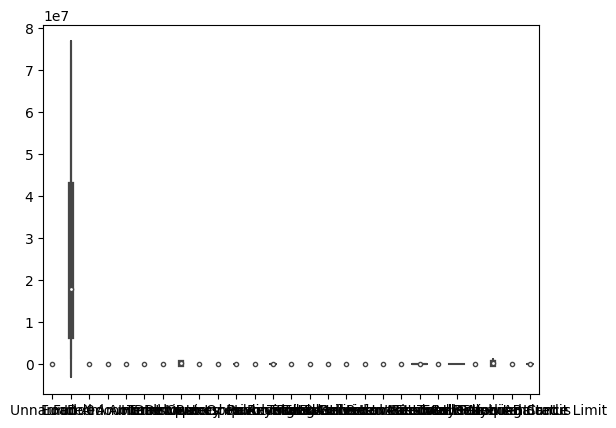

In [22]:
sns.violinplot(combined)

/tmp/ipykernel_20/3062371967.py:1: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(combined)


<AxesSubplot: ylabel='Density'>

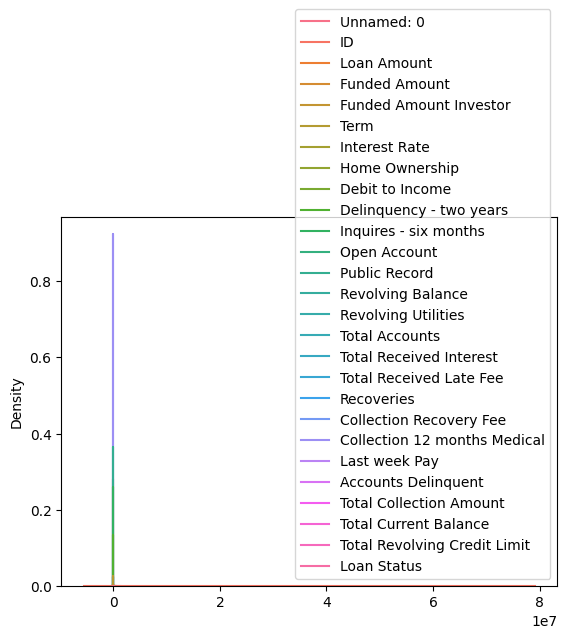

In [23]:
sns.kdeplot(combined)

<AxesSubplot: >

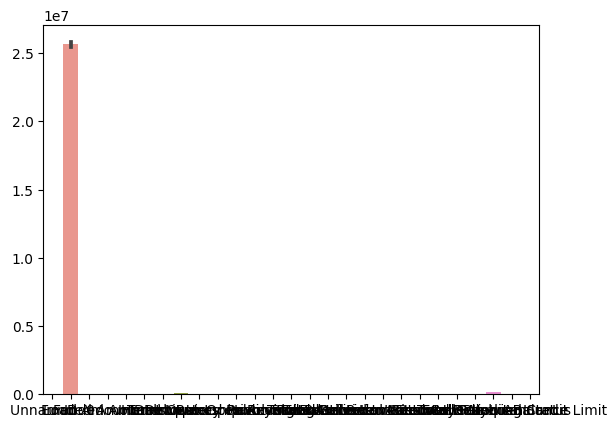

In [24]:
sns.barplot(combined)

In [25]:
cat_cols = combined.select_dtypes(include='object')

In [26]:
for i in cat_cols:
    print(i)
    print(combined[i].value_counts())
    print('_'*50)

Batch Enrolled
BAT3873588    3626
BAT1586599    3142
BAT1104812    2996
BAT2252229    2557
BAT2803411    2425
BAT1780517    2403
BAT1184694    2298
BAT2078974    2290
BAT2575549    2257
BAT4694572    2248
BAT4271519    2054
BAT2558388    1963
BAT3193689    1864
BAT1930365    1844
BAT2136391    1790
BAT2333412    1775
BAT3726927    1774
BAT4136152    1766
BAT5341619    1717
BAT5525466    1709
BAT5489674    1677
BAT5629144    1639
BAT1766061    1461
BAT2833642    1421
BAT5924421    1404
BAT2522922    1399
BAT2428731    1398
BAT4808022    1303
BAT4351734    1140
BAT5547201    1127
BAT5714674    1105
BAT3461431    1068
BAT224923      895
BAT1761981     894
BAT4722912     887
BAT2003848     842
BAT1467036     802
BAT5849876     768
BAT3865626     728
BAT5811547     711
BAT1135695     296
Name: Batch Enrolled, dtype: int64
__________________________________________________
Grade
C    19085
B    18742
A    12055
D     8259
E     6446
F     2246
G      630
Name: Grade, dtype: int64
___________

In [27]:
num_cols = combined.select_dtypes (include='number')

In [28]:
for i in num_cols:
    print(i)
    print(combined[i].value_counts())
    print('_'*50)

Unnamed: 0
58459    1
65963    1
57986    1
51785    1
53781    1
        ..
4084     1
17551    1
43872    1
42265    1
36913    1
Name: Unnamed: 0, Length: 67463, dtype: int64
__________________________________________________
ID
57890399    1
22092359    1
15638387    1
1641909     1
65377932    1
           ..
3364999     1
27757732    1
9036991     1
40777726    1
1796551     1
Name: ID, Length: 67463, dtype: int64
__________________________________________________
Loan Amount
15932    13
14424    12
14556    11
14689    11
15118    11
         ..
24030     1
31209     1
26398     1
30154     1
3723      1
Name: Loan Amount, Length: 27525, dtype: int64
__________________________________________________
Funded Amount
10835    16
11034    15
10728    14
11451    14
7691     14
         ..
23730     1
34608     1
28935     1
17672     1
30633     1
Name: Funded Amount, Length: 24548, dtype: int64
__________________________________________________
Funded Amount Investor
14238.25035   

In [29]:
combined['Unnamed: 0']=combined['Unnamed: 0'].map({'Good':2,'Standard':1,'Poor':0})

/tmp/ipykernel_20/664620698.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(combined.corr(),annot=True,cmap='afmhot_r')


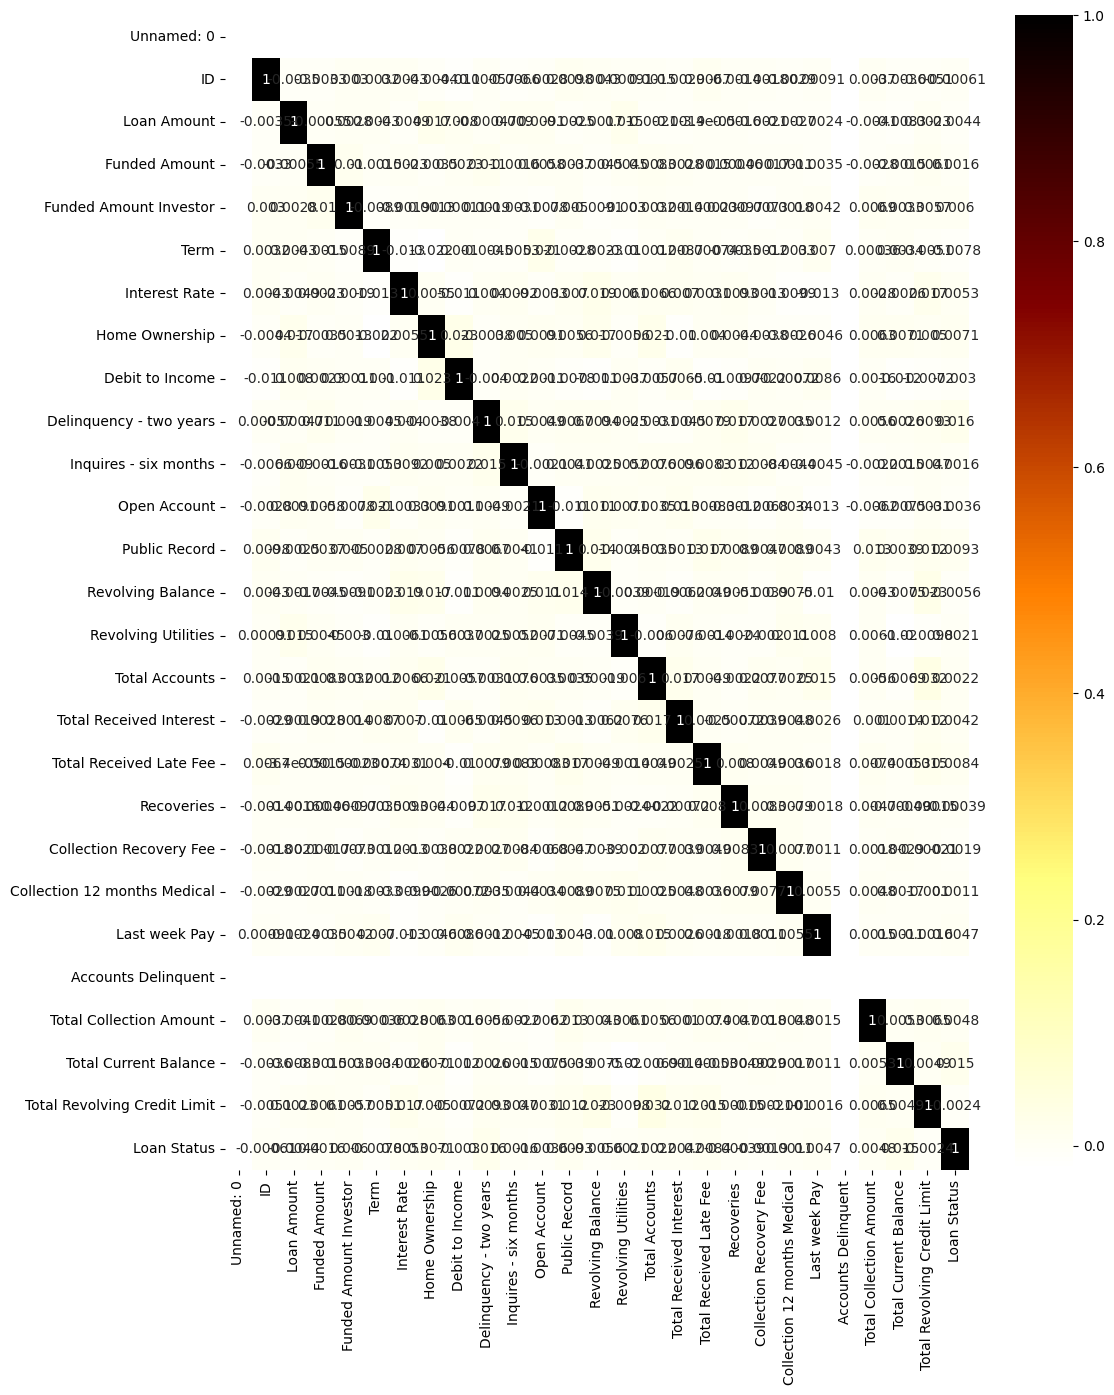

In [30]:
plt.figure(figsize=(12,15))
sns.heatmap(combined.corr(),annot=True,cmap='afmhot_r')
plt.show()

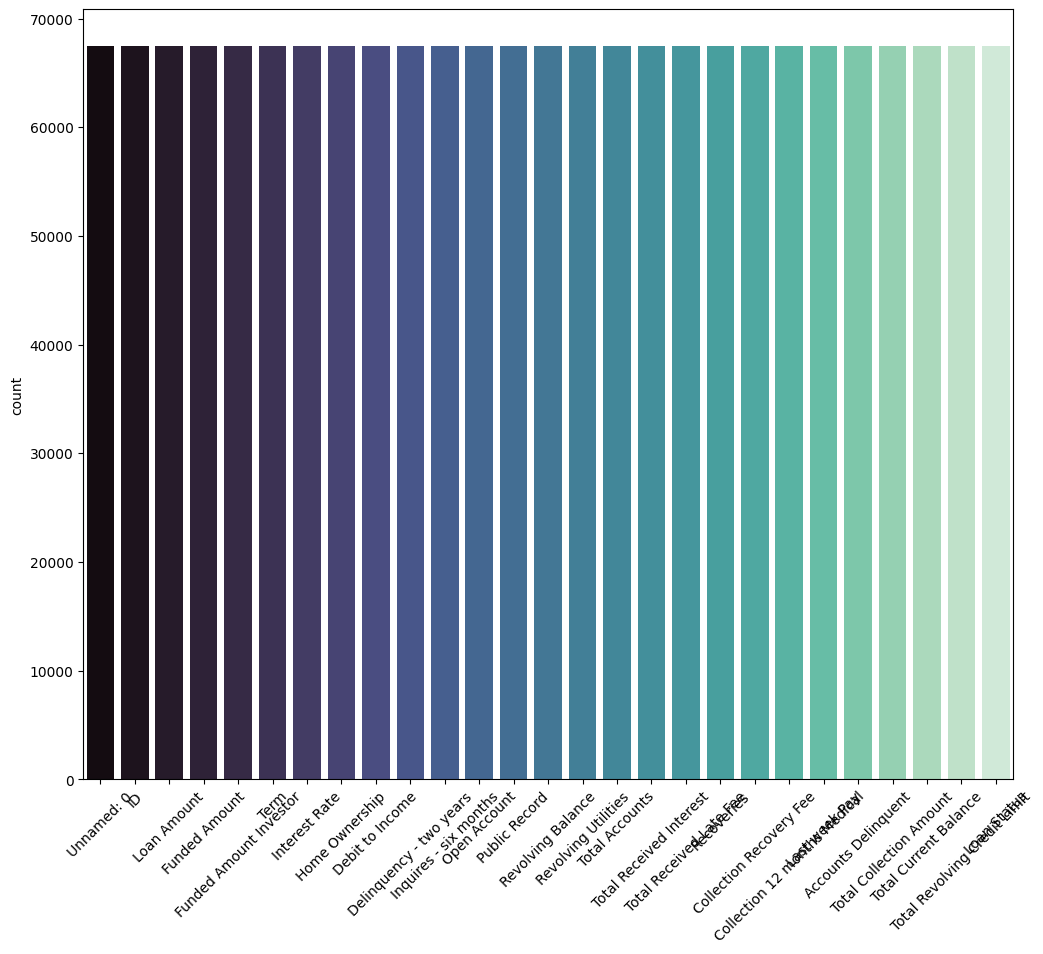

In [31]:
plt.figure(figsize=(12,10))
sns.countplot(combined,palette='mako');
plt.xticks(rotation=45);

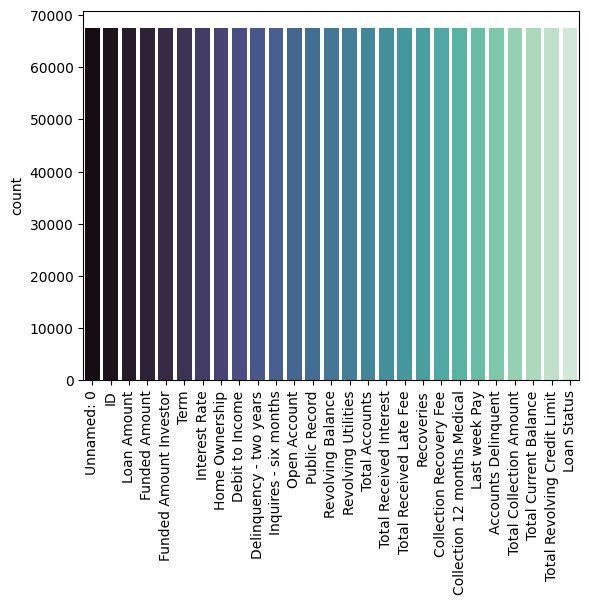

In [32]:
sns.countplot(combined,palette='mako');
plt.xticks(rotation=90);

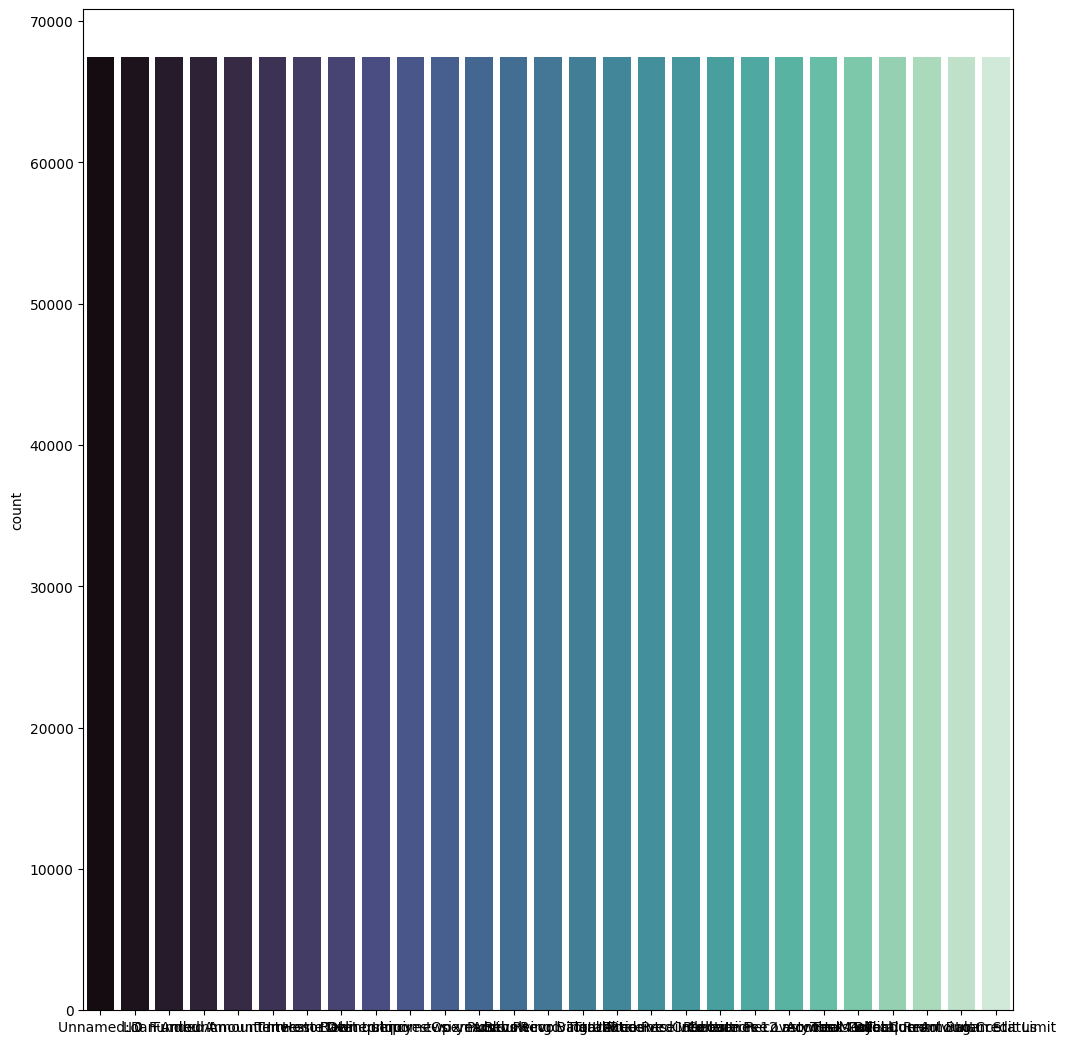

In [33]:
plt.figure(figsize=(12,13))
sns.countplot(combined,palette='mako')
plt.show()

In [34]:
combined['Unnamed: 0'].value_counts()

Series([], Name: Unnamed: 0, dtype: int64)

In [35]:
combined['Unnamed: 0'].unique()

array([nan])

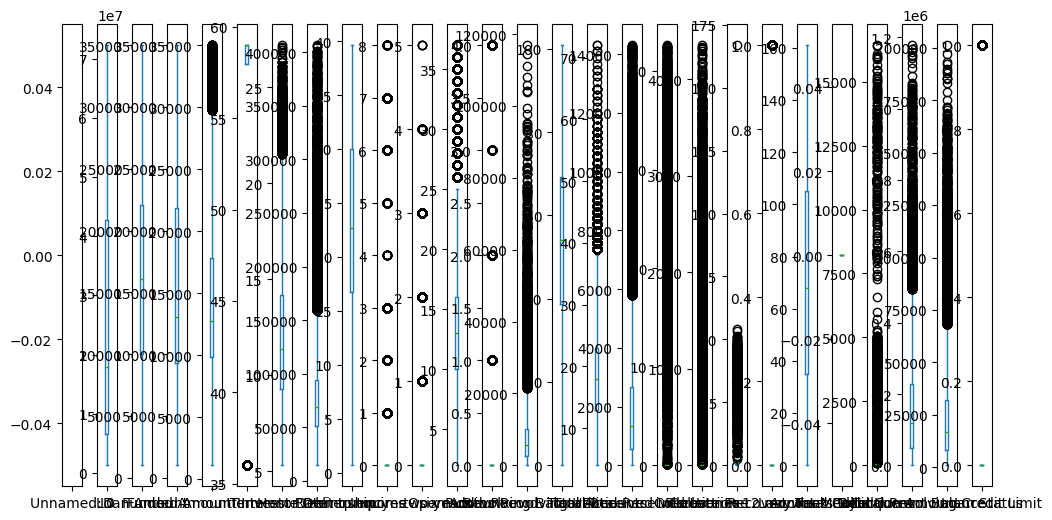

In [36]:
combined.plot(kind='box',subplots = True, sharey=False, figsize=(12,6))

plt.subplots_adjust(wspace=0.75)
plt.show()

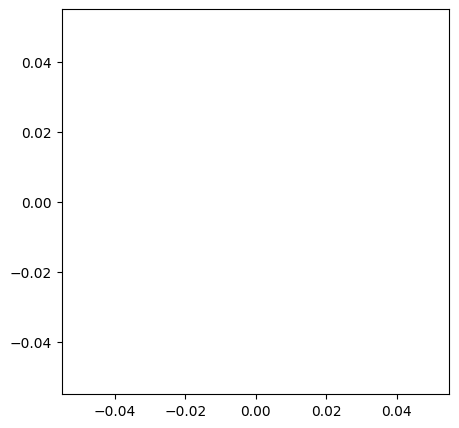

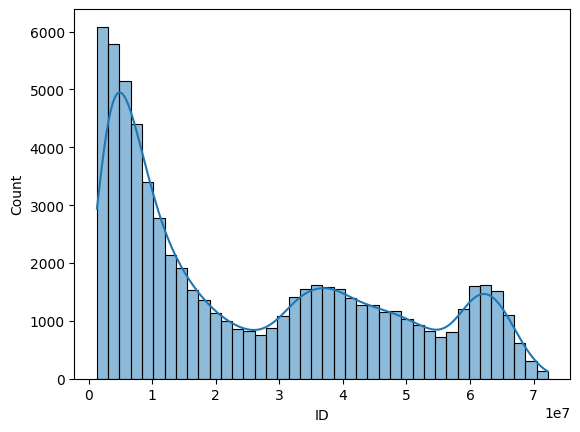

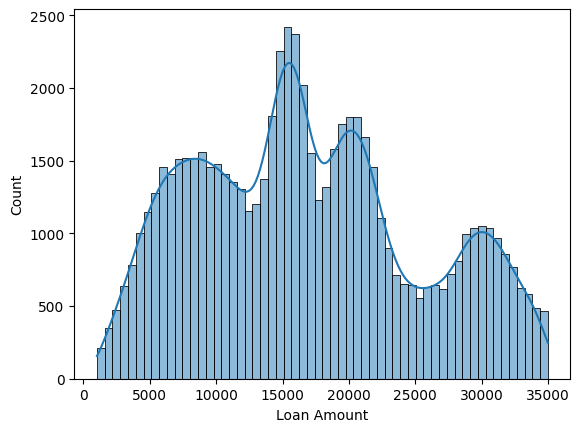

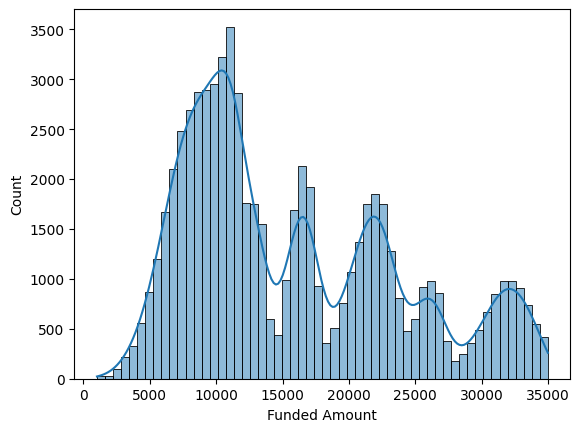

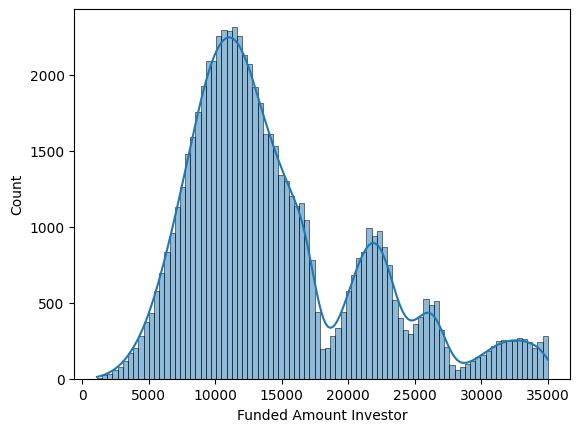

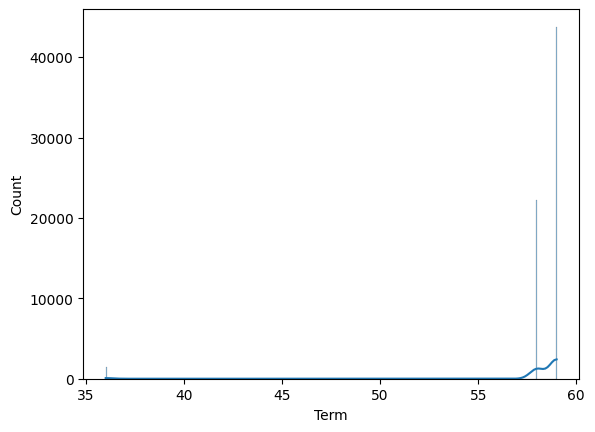

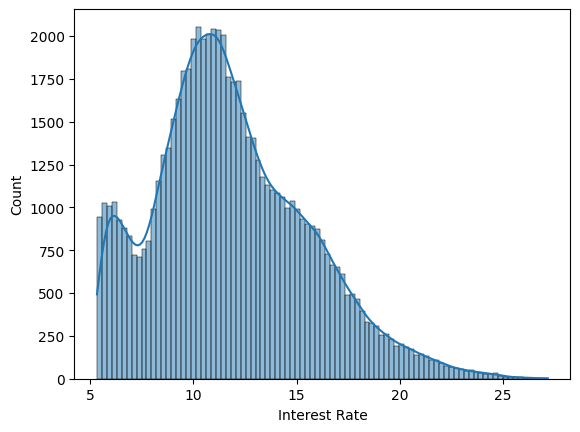

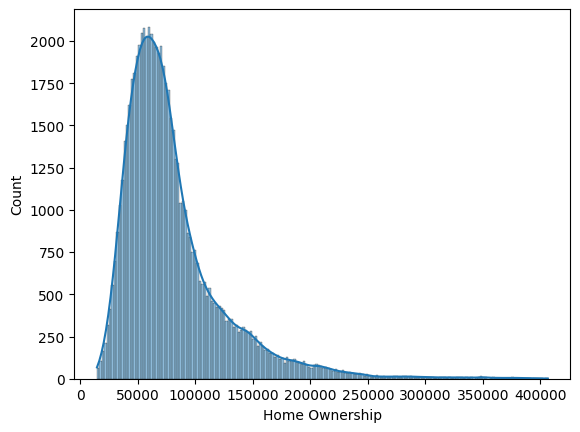

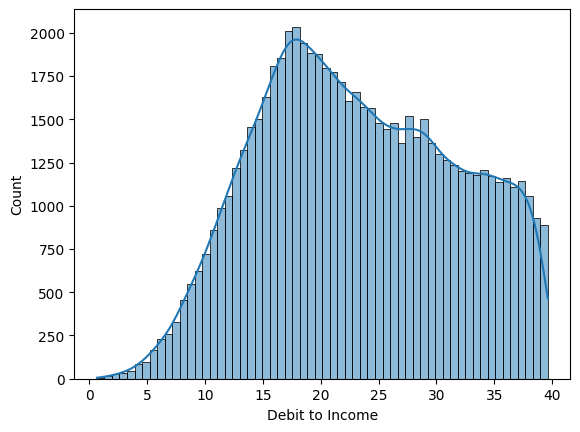

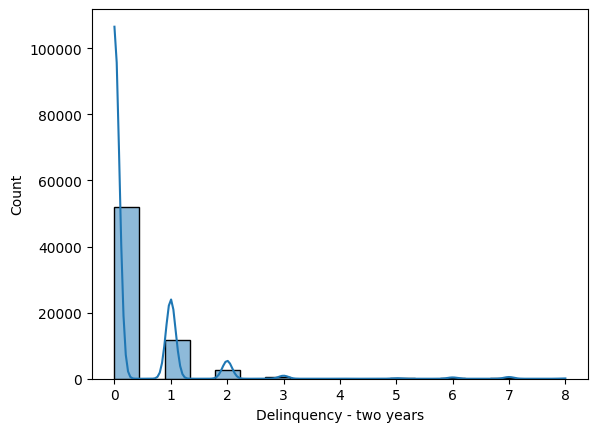

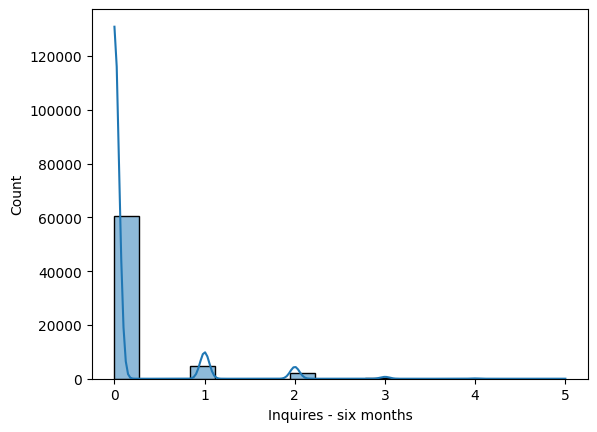

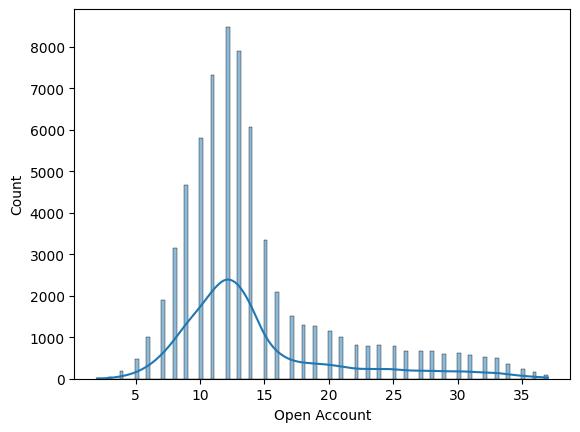

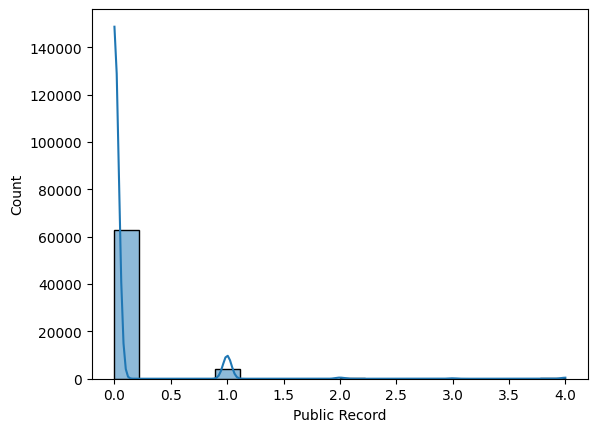

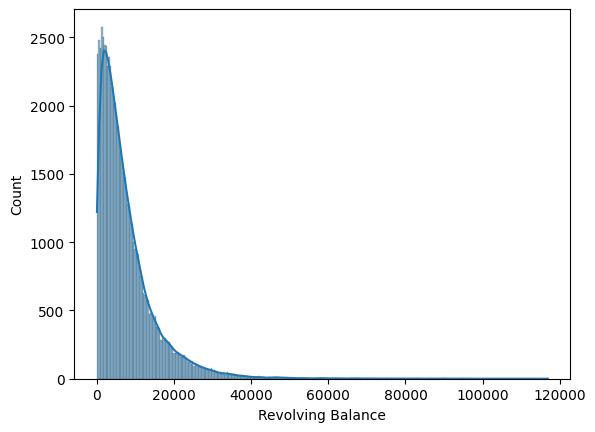

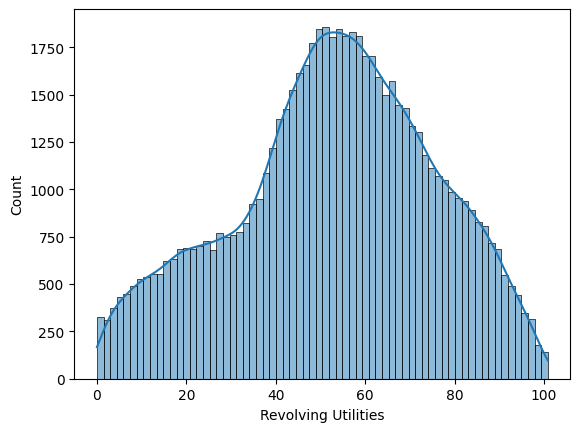

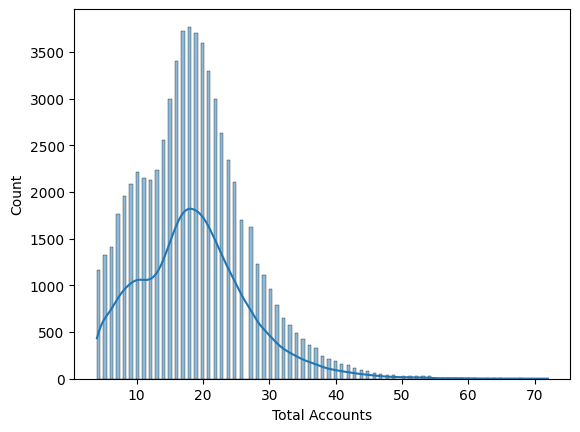

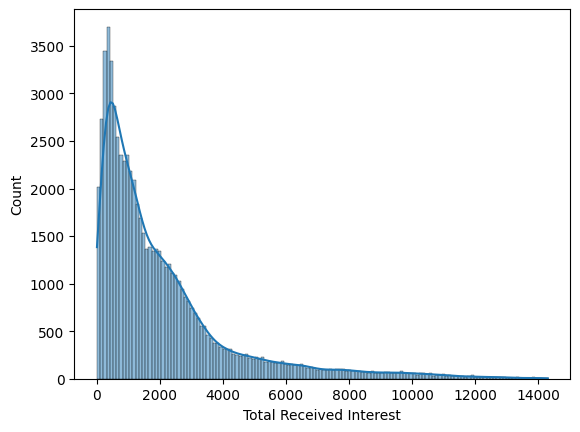

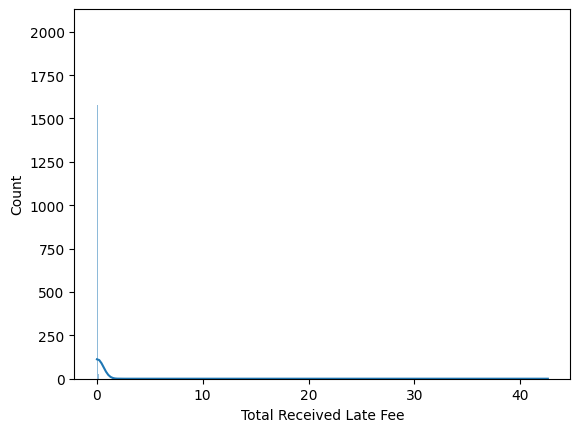

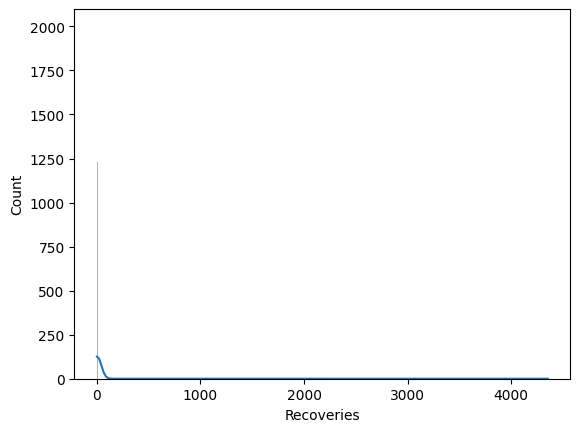

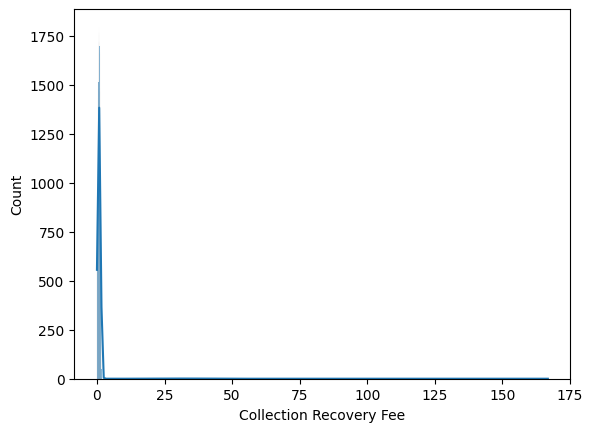

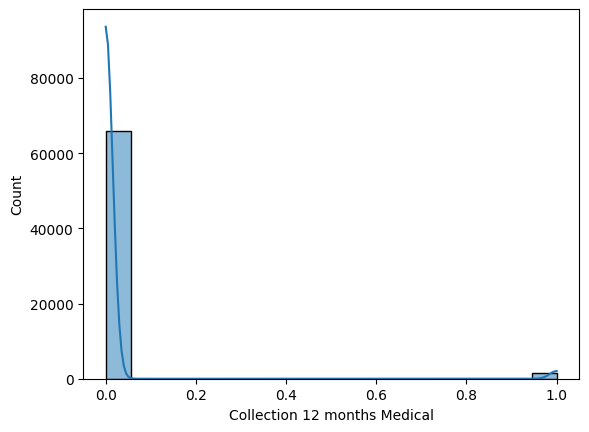

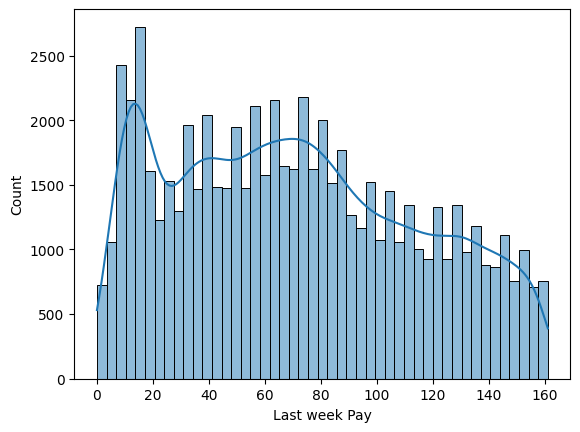

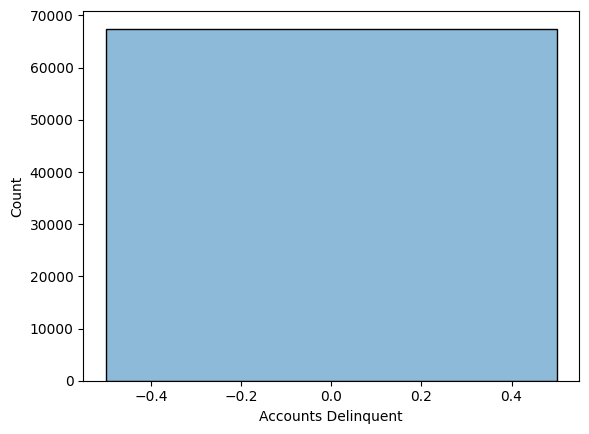

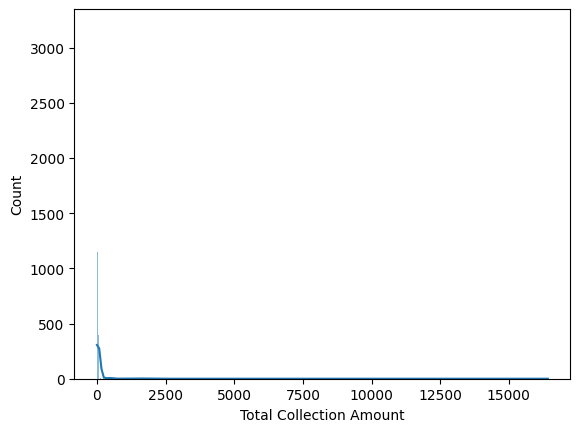

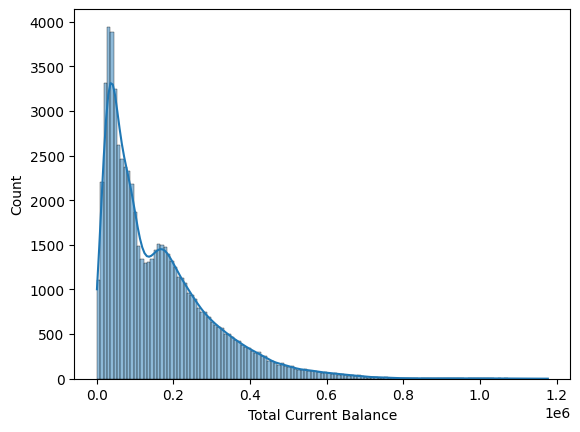

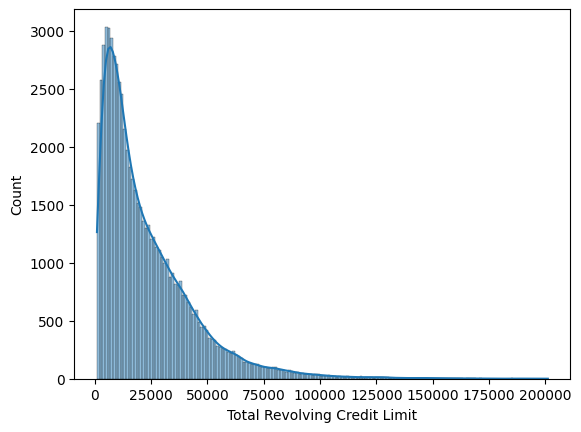

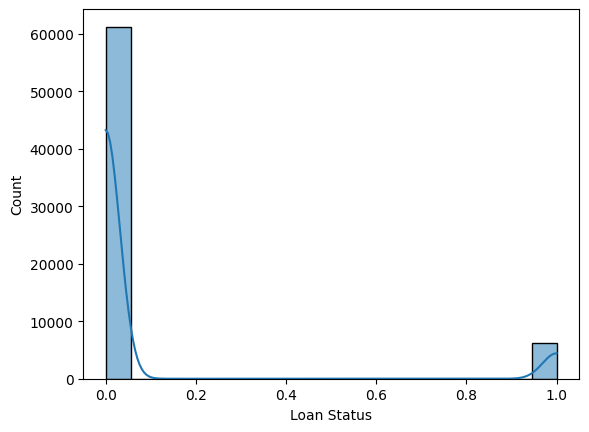

In [37]:
plt.figure(figsize=(5,5))
x=1
for i in num_cols:
    sns.histplot(data=combined,x=i,kde=True)
    print('\n')
    plt.show()

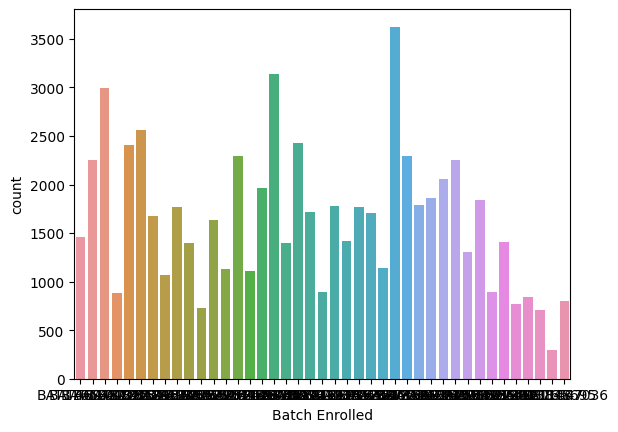

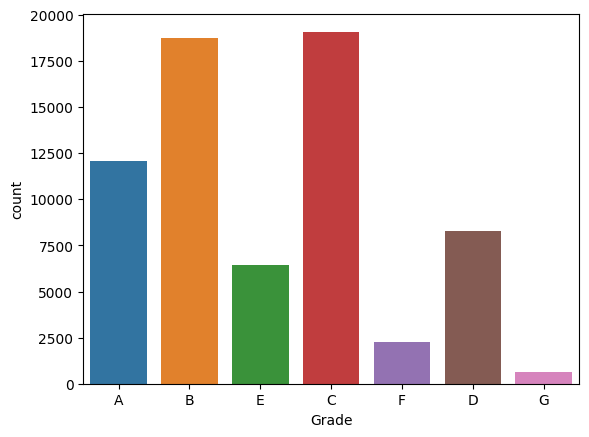

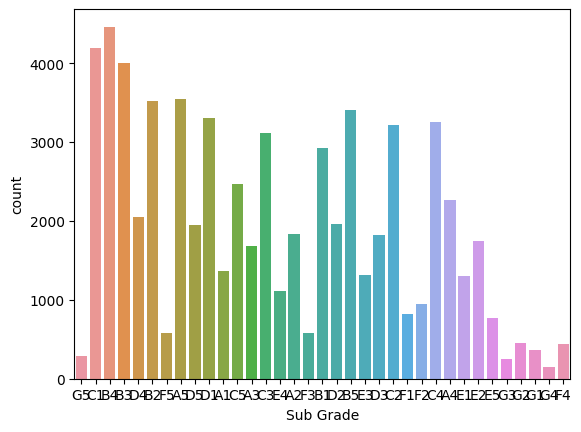

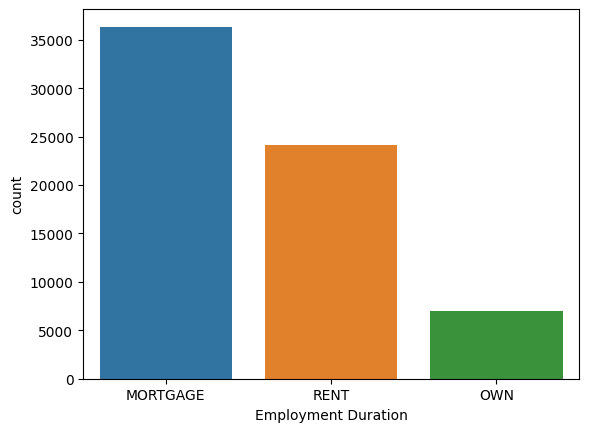

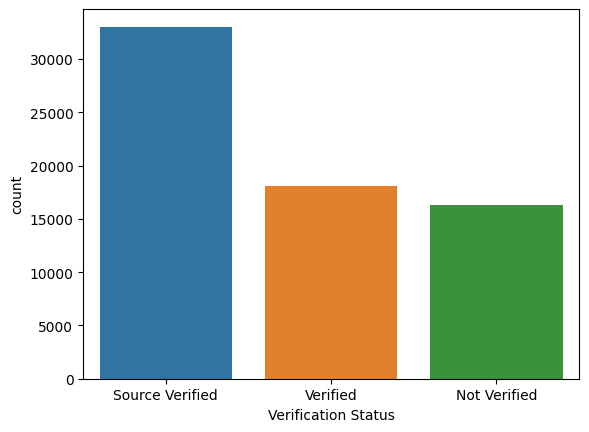

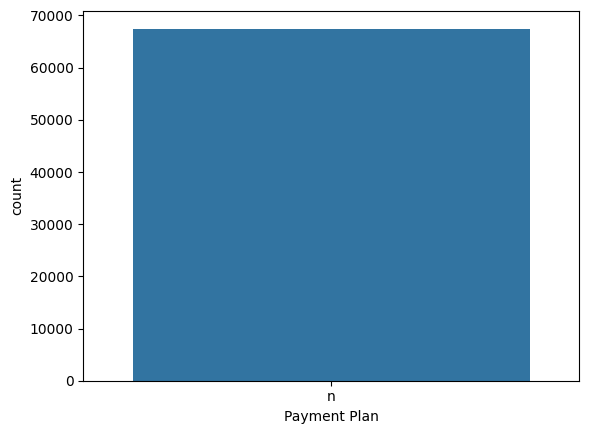

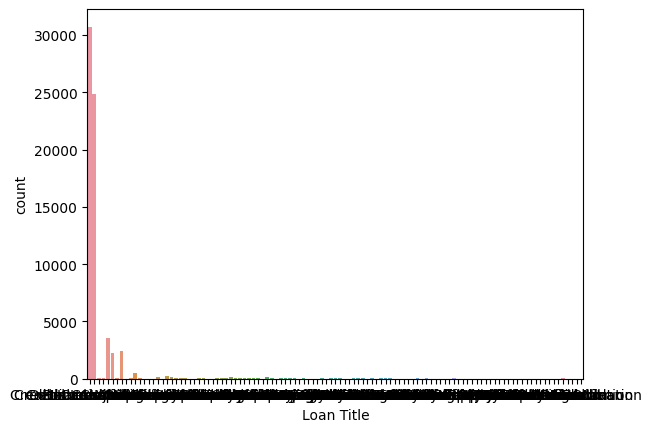

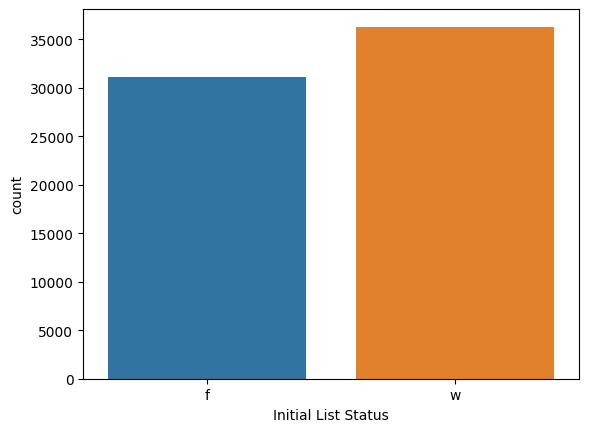

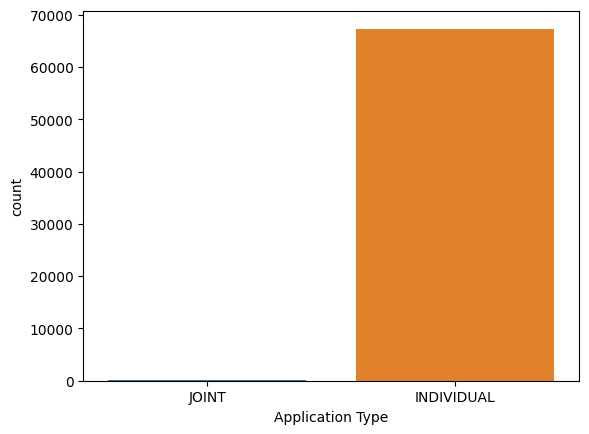

In [38]:
x=1
for i in cat_cols:
    sns.countplot(data=combined,x=i)
    print('\n')

    plt.show()

In [39]:
# Replacing weird values
combined = combined.applymap(lambda x:x if x is np.NaN or not isinstance(x,str)else str(x).strip('_,)"')
                            ).replace(['','nan','!@9#%8','#F%$D@*@8'],np.NaN)

In [40]:
combined.head()

,Unnamed: 0,ID,Loan Amount,Funded Amount,Funded Amount Investor,Term,Batch Enrolled,Interest Rate,Grade,Sub Grade,Employment Duration,Home Ownership,Verification Status,Payment Plan,Loan Title,Debit to Income,Delinquency - two years,Inquires - six months,Open Account,Public Record,Revolving Balance,Revolving Utilities,Total Accounts,Initial List Status,Total Received Interest,Total Received Late Fee,Recoveries,Collection Recovery Fee,Collection 12 months Medical,Application Type,Last week Pay,Accounts Delinquent,Total Collection Amount,Total Current Balance,Total Revolving Credit Limit,Loan Status
0,NaN,57890399,14986,6848,14215.834900,58,BAT1766061,17.841656,A,G5,MORTGAGE,66291.22833,Source Verified,n,Credit card refinancing,22.628291,0,0,16,0,8993,34.734212,16,f,4694.025115,0.000056,5.460927,0.692790,0,JOINT,159,0,41,16762,6137,0.0
1,NaN,14627222,25795,5588,10972.781160,58,BAT4694572,11.655297,B,C1,MORTGAGE,78002.00947,Source Verified,n,Debt consolidation,12.321649,1,0,29,0,18158,87.503244,10,w,5224.407117,0.056749,1.390781,1.415970,0,INDIVIDUAL,141,0,21,411722,8417,0.0
2,NaN,63209318,4200,16786,7370.911374,59,BAT1104812,10.499741,B,B4,RENT,71538.83031,Source Verified,n,Credit card refinancing,32.920842,1,0,6,0,2219,62.248790,10,f,476.065484,0.011840,4.888484,1.410109,0,INDIVIDUAL,152,0,20,70438,6932,0.0
3,NaN,5295524,17148,21912,4840.020550,59,BAT4722912,14.274406,E,B3,OWN,49315.79444,Source Verified,n,Credit card refinance,25.514694,0,3,17,0,17976,38.034926,22,f,223.889079,20.264162,0.842342,0.693088,0,INDIVIDUAL,145,0,17,414692,19552,0.0
4,NaN,27540920,20848,11668,13408.689070,59,BAT1104812,10.343987,C,D4,MORTGAGE,45261.55641,Verified,n,Credit card refinancing,13.528166,0,0,9,0,7650,52.413628,10,w,642.600925,0.003445,2.834972,0.667659,0,INDIVIDUAL,106,0,49,49760,34135,0.0


In [41]:
 # Treating type of Unnamed: 0
combined['Unnamed: 0'].value_counts().head(9).index[1:]

Float64Index([], dtype='float64')

In [42]:
combined['Unnamed: 0'].unique()

array([nan])

In [43]:
combined['Interest Rate']=combined['Interest Rate'].astype(float)

In [44]:
extreme = combined[(combined['Interest Rate']>85)|(combined['Interest Rate']<0)].index

In [45]:
for i in extreme:
    combined.loc[i,'Interest Rate']=np.nan

In [46]:
combined.head()

,Unnamed: 0,ID,Loan Amount,Funded Amount,Funded Amount Investor,Term,Batch Enrolled,Interest Rate,Grade,Sub Grade,Employment Duration,Home Ownership,Verification Status,Payment Plan,Loan Title,Debit to Income,Delinquency - two years,Inquires - six months,Open Account,Public Record,Revolving Balance,Revolving Utilities,Total Accounts,Initial List Status,Total Received Interest,Total Received Late Fee,Recoveries,Collection Recovery Fee,Collection 12 months Medical,Application Type,Last week Pay,Accounts Delinquent,Total Collection Amount,Total Current Balance,Total Revolving Credit Limit,Loan Status
0,NaN,57890399,14986,6848,14215.834900,58,BAT1766061,17.841656,A,G5,MORTGAGE,66291.22833,Source Verified,n,Credit card refinancing,22.628291,0,0,16,0,8993,34.734212,16,f,4694.025115,0.000056,5.460927,0.692790,0,JOINT,159,0,41,16762,6137,0.0
1,NaN,14627222,25795,5588,10972.781160,58,BAT4694572,11.655297,B,C1,MORTGAGE,78002.00947,Source Verified,n,Debt consolidation,12.321649,1,0,29,0,18158,87.503244,10,w,5224.407117,0.056749,1.390781,1.415970,0,INDIVIDUAL,141,0,21,411722,8417,0.0
2,NaN,63209318,4200,16786,7370.911374,59,BAT1104812,10.499741,B,B4,RENT,71538.83031,Source Verified,n,Credit card refinancing,32.920842,1,0,6,0,2219,62.248790,10,f,476.065484,0.011840,4.888484,1.410109,0,INDIVIDUAL,152,0,20,70438,6932,0.0
3,NaN,5295524,17148,21912,4840.020550,59,BAT4722912,14.274406,E,B3,OWN,49315.79444,Source Verified,n,Credit card refinance,25.514694,0,3,17,0,17976,38.034926,22,f,223.889079,20.264162,0.842342,0.693088,0,INDIVIDUAL,145,0,17,414692,19552,0.0
4,NaN,27540920,20848,11668,13408.689070,59,BAT1104812,10.343987,C,D4,MORTGAGE,45261.55641,Verified,n,Credit card refinancing,13.528166,0,0,9,0,7650,52.413628,10,w,642.600925,0.003445,2.834972,0.667659,0,INDIVIDUAL,106,0,49,49760,34135,0.0


In [47]:
mapping = combined.groupby('Unnamed: 0')['Interest Rate'].mean().to_dict()

In [48]:
combined['Interest Rate']=combined['Unnamed: 0'].map(mapping)

In [49]:
combined['Interest Rate']=round(combined['Interest Rate'],0)

In [50]:
combined['Interest Rate']=combined['Interest Rate'].astype(str)

In [51]:
combined.head()

,Unnamed: 0,ID,Loan Amount,Funded Amount,Funded Amount Investor,Term,Batch Enrolled,Interest Rate,Grade,Sub Grade,Employment Duration,Home Ownership,Verification Status,Payment Plan,Loan Title,Debit to Income,Delinquency - two years,Inquires - six months,Open Account,Public Record,Revolving Balance,Revolving Utilities,Total Accounts,Initial List Status,Total Received Interest,Total Received Late Fee,Recoveries,Collection Recovery Fee,Collection 12 months Medical,Application Type,Last week Pay,Accounts Delinquent,Total Collection Amount,Total Current Balance,Total Revolving Credit Limit,Loan Status
0,NaN,57890399,14986,6848,14215.834900,58,BAT1766061,nan,A,G5,MORTGAGE,66291.22833,Source Verified,n,Credit card refinancing,22.628291,0,0,16,0,8993,34.734212,16,f,4694.025115,0.000056,5.460927,0.692790,0,JOINT,159,0,41,16762,6137,0.0
1,NaN,14627222,25795,5588,10972.781160,58,BAT4694572,nan,B,C1,MORTGAGE,78002.00947,Source Verified,n,Debt consolidation,12.321649,1,0,29,0,18158,87.503244,10,w,5224.407117,0.056749,1.390781,1.415970,0,INDIVIDUAL,141,0,21,411722,8417,0.0
2,NaN,63209318,4200,16786,7370.911374,59,BAT1104812,nan,B,B4,RENT,71538.83031,Source Verified,n,Credit card refinancing,32.920842,1,0,6,0,2219,62.248790,10,f,476.065484,0.011840,4.888484,1.410109,0,INDIVIDUAL,152,0,20,70438,6932,0.0
3,NaN,5295524,17148,21912,4840.020550,59,BAT4722912,nan,E,B3,OWN,49315.79444,Source Verified,n,Credit card refinance,25.514694,0,3,17,0,17976,38.034926,22,f,223.889079,20.264162,0.842342,0.693088,0,INDIVIDUAL,145,0,17,414692,19552,0.0
4,NaN,27540920,20848,11668,13408.689070,59,BAT1104812,nan,C,D4,MORTGAGE,45261.55641,Verified,n,Credit card refinancing,13.528166,0,0,9,0,7650,52.413628,10,w,642.600925,0.003445,2.834972,0.667659,0,INDIVIDUAL,106,0,49,49760,34135,0.0


In [52]:
combined.isnull().sum()

Unnamed: 0                      67463
ID                                  0
Loan Amount                         0
Funded Amount                       0
Funded Amount Investor              0
Term                                0
Batch Enrolled                      0
Interest Rate                       0
Grade                               0
Sub Grade                           0
Employment Duration                 0
Home Ownership                      0
Verification Status                 0
Payment Plan                        0
Loan Title                          0
Debit to Income                     0
Delinquency - two years             0
Inquires - six months               0
Open Account                        0
Public Record                       0
Revolving Balance                   0
Revolving Utilities                 0
Total Accounts                      0
Initial List Status                 0
Total Received Interest             0
Total Received Late Fee             0
Recoveries  

In [53]:
combined['Interest Rate'].value_counts()

nan    67463
Name: Interest Rate, dtype: int64

In [54]:
combined['Interest Rate']=combined['Interest Rate'].replace({'NM':'Other'})

In [55]:
combined['Interest Rate'].value_counts()

nan    67463
Name: Interest Rate, dtype: int64

In [56]:
# Treating null values Unnamed: 0
mapping = combined.groupby('Unnamed: 0').median()['ID'].to_dict()

/tmp/ipykernel_20/2509546817.py:2: FutureWarning: The default value of numeric_only in DataFrameGroupBy.median is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  mapping = combined.groupby('Unnamed: 0').median()['ID'].to_dict()


In [57]:
combined['ID']=combined['Unnamed: 0'].map(mapping)

In [58]:
combined['ID']=round(combined['ID'],0)

In [59]:
combined['ID'].value_counts()

Series([], Name: ID, dtype: int64)

In [60]:
# treating null value Loan Amount
combined.groupby('ID')['Loan Amount'].apply(lambda x:x.fillna(x.mode()[0]))

/tmp/ipykernel_20/1664145511.py:2: FutureWarning: Not prepending group keys to the result index of transform-like apply. In the future, the group keys will be included in the index, regardless of whether the applied function returns a like-indexed object.
To preserve the previous behavior, use

	>>> .groupby(..., group_keys=False)

To adopt the future behavior and silence this warning, use 

	>>> .groupby(..., group_keys=True)
  combined.groupby('ID')['Loan Amount'].apply(lambda x:x.fillna(x.mode()[0]))


Series([], Name: Loan Amount, dtype: int64)

In [61]:
map1 = combined.groupby(['Unnamed: 0'])['ID'].agg(pd.Series.mode).to_dict()

In [62]:
combined['ID']=combined['Unnamed: 0'].map(map1)

In [63]:
combined['ID'].isnull().sum()

67463

In [64]:
combined.head()

,Unnamed: 0,ID,Loan Amount,Funded Amount,Funded Amount Investor,Term,Batch Enrolled,Interest Rate,Grade,Sub Grade,Employment Duration,Home Ownership,Verification Status,Payment Plan,Loan Title,Debit to Income,Delinquency - two years,Inquires - six months,Open Account,Public Record,Revolving Balance,Revolving Utilities,Total Accounts,Initial List Status,Total Received Interest,Total Received Late Fee,Recoveries,Collection Recovery Fee,Collection 12 months Medical,Application Type,Last week Pay,Accounts Delinquent,Total Collection Amount,Total Current Balance,Total Revolving Credit Limit,Loan Status
0,NaN,NaN,14986,6848,14215.834900,58,BAT1766061,nan,A,G5,MORTGAGE,66291.22833,Source Verified,n,Credit card refinancing,22.628291,0,0,16,0,8993,34.734212,16,f,4694.025115,0.000056,5.460927,0.692790,0,JOINT,159,0,41,16762,6137,0.0
1,NaN,NaN,25795,5588,10972.781160,58,BAT4694572,nan,B,C1,MORTGAGE,78002.00947,Source Verified,n,Debt consolidation,12.321649,1,0,29,0,18158,87.503244,10,w,5224.407117,0.056749,1.390781,1.415970,0,INDIVIDUAL,141,0,21,411722,8417,0.0
2,NaN,NaN,4200,16786,7370.911374,59,BAT1104812,nan,B,B4,RENT,71538.83031,Source Verified,n,Credit card refinancing,32.920842,1,0,6,0,2219,62.248790,10,f,476.065484,0.011840,4.888484,1.410109,0,INDIVIDUAL,152,0,20,70438,6932,0.0
3,NaN,NaN,17148,21912,4840.020550,59,BAT4722912,nan,E,B3,OWN,49315.79444,Source Verified,n,Credit card refinance,25.514694,0,3,17,0,17976,38.034926,22,f,223.889079,20.264162,0.842342,0.693088,0,INDIVIDUAL,145,0,17,414692,19552,0.0
4,NaN,NaN,20848,11668,13408.689070,59,BAT1104812,nan,C,D4,MORTGAGE,45261.55641,Verified,n,Credit card refinancing,13.528166,0,0,9,0,7650,52.413628,10,w,642.600925,0.003445,2.834972,0.667659,0,INDIVIDUAL,106,0,49,49760,34135,0.0


In [65]:
# Treating null value of Loan Amount
map2 = combined.groupby(['Unnamed: 0'])['Loan Amount'].mean().to_dict()

In [66]:
combined['Loan Amount']=combined['Unnamed: 0'].map(map2)

In [67]:
combined.head()

,Unnamed: 0,ID,Loan Amount,Funded Amount,Funded Amount Investor,Term,Batch Enrolled,Interest Rate,Grade,Sub Grade,Employment Duration,Home Ownership,Verification Status,Payment Plan,Loan Title,Debit to Income,Delinquency - two years,Inquires - six months,Open Account,Public Record,Revolving Balance,Revolving Utilities,Total Accounts,Initial List Status,Total Received Interest,Total Received Late Fee,Recoveries,Collection Recovery Fee,Collection 12 months Medical,Application Type,Last week Pay,Accounts Delinquent,Total Collection Amount,Total Current Balance,Total Revolving Credit Limit,Loan Status
0,NaN,NaN,NaN,6848,14215.834900,58,BAT1766061,nan,A,G5,MORTGAGE,66291.22833,Source Verified,n,Credit card refinancing,22.628291,0,0,16,0,8993,34.734212,16,f,4694.025115,0.000056,5.460927,0.692790,0,JOINT,159,0,41,16762,6137,0.0
1,NaN,NaN,NaN,5588,10972.781160,58,BAT4694572,nan,B,C1,MORTGAGE,78002.00947,Source Verified,n,Debt consolidation,12.321649,1,0,29,0,18158,87.503244,10,w,5224.407117,0.056749,1.390781,1.415970,0,INDIVIDUAL,141,0,21,411722,8417,0.0
2,NaN,NaN,NaN,16786,7370.911374,59,BAT1104812,nan,B,B4,RENT,71538.83031,Source Verified,n,Credit card refinancing,32.920842,1,0,6,0,2219,62.248790,10,f,476.065484,0.011840,4.888484,1.410109,0,INDIVIDUAL,152,0,20,70438,6932,0.0
3,NaN,NaN,NaN,21912,4840.020550,59,BAT4722912,nan,E,B3,OWN,49315.79444,Source Verified,n,Credit card refinance,25.514694,0,3,17,0,17976,38.034926,22,f,223.889079,20.264162,0.842342,0.693088,0,INDIVIDUAL,145,0,17,414692,19552,0.0
4,NaN,NaN,NaN,11668,13408.689070,59,BAT1104812,nan,C,D4,MORTGAGE,45261.55641,Verified,n,Credit card refinancing,13.528166,0,0,9,0,7650,52.413628,10,w,642.600925,0.003445,2.834972,0.667659,0,INDIVIDUAL,106,0,49,49760,34135,0.0


In [68]:
# Treating null of Funded Amount with help of Unnamed: 0
combined['Funded Amount']=combined['Funded Amount'].astype(float)

In [69]:
map3 = combined.groupby('Unnamed: 0')['Funded Amount'].median().to_dict()

In [70]:
combined['Funded Amount']=combined['Unnamed: 0'].map(map3)

In [71]:
combined['Funded Amount']=round(combined['Funded Amount'],0)

In [72]:
combined.head()

,Unnamed: 0,ID,Loan Amount,Funded Amount,Funded Amount Investor,Term,Batch Enrolled,Interest Rate,Grade,Sub Grade,Employment Duration,Home Ownership,Verification Status,Payment Plan,Loan Title,Debit to Income,Delinquency - two years,Inquires - six months,Open Account,Public Record,Revolving Balance,Revolving Utilities,Total Accounts,Initial List Status,Total Received Interest,Total Received Late Fee,Recoveries,Collection Recovery Fee,Collection 12 months Medical,Application Type,Last week Pay,Accounts Delinquent,Total Collection Amount,Total Current Balance,Total Revolving Credit Limit,Loan Status
0,NaN,NaN,NaN,NaN,14215.834900,58,BAT1766061,nan,A,G5,MORTGAGE,66291.22833,Source Verified,n,Credit card refinancing,22.628291,0,0,16,0,8993,34.734212,16,f,4694.025115,0.000056,5.460927,0.692790,0,JOINT,159,0,41,16762,6137,0.0
1,NaN,NaN,NaN,NaN,10972.781160,58,BAT4694572,nan,B,C1,MORTGAGE,78002.00947,Source Verified,n,Debt consolidation,12.321649,1,0,29,0,18158,87.503244,10,w,5224.407117,0.056749,1.390781,1.415970,0,INDIVIDUAL,141,0,21,411722,8417,0.0
2,NaN,NaN,NaN,NaN,7370.911374,59,BAT1104812,nan,B,B4,RENT,71538.83031,Source Verified,n,Credit card refinancing,32.920842,1,0,6,0,2219,62.248790,10,f,476.065484,0.011840,4.888484,1.410109,0,INDIVIDUAL,152,0,20,70438,6932,0.0
3,NaN,NaN,NaN,NaN,4840.020550,59,BAT4722912,nan,E,B3,OWN,49315.79444,Source Verified,n,Credit card refinance,25.514694,0,3,17,0,17976,38.034926,22,f,223.889079,20.264162,0.842342,0.693088,0,INDIVIDUAL,145,0,17,414692,19552,0.0
4,NaN,NaN,NaN,NaN,13408.689070,59,BAT1104812,nan,C,D4,MORTGAGE,45261.55641,Verified,n,Credit card refinancing,13.528166,0,0,9,0,7650,52.413628,10,w,642.600925,0.003445,2.834972,0.667659,0,INDIVIDUAL,106,0,49,49760,34135,0.0


In [73]:
# treating null of Funded Amount Investor with help of Unnamed: 0
map4 = combined.groupby('Unnamed: 0')['Funded Amount Investor'].agg(pd.Series.mode).to_dict()

In [74]:
combined['Funded Amount Investor']=combined['Unnamed: 0'].map(map4)

In [75]:
combined['Term'].dtypes

dtype('int64')

In [76]:
combined.head()

,Unnamed: 0,ID,Loan Amount,Funded Amount,Funded Amount Investor,Term,Batch Enrolled,Interest Rate,Grade,Sub Grade,Employment Duration,Home Ownership,Verification Status,Payment Plan,Loan Title,Debit to Income,Delinquency - two years,Inquires - six months,Open Account,Public Record,Revolving Balance,Revolving Utilities,Total Accounts,Initial List Status,Total Received Interest,Total Received Late Fee,Recoveries,Collection Recovery Fee,Collection 12 months Medical,Application Type,Last week Pay,Accounts Delinquent,Total Collection Amount,Total Current Balance,Total Revolving Credit Limit,Loan Status
0,NaN,NaN,NaN,NaN,NaN,58,BAT1766061,nan,A,G5,MORTGAGE,66291.22833,Source Verified,n,Credit card refinancing,22.628291,0,0,16,0,8993,34.734212,16,f,4694.025115,0.000056,5.460927,0.692790,0,JOINT,159,0,41,16762,6137,0.0
1,NaN,NaN,NaN,NaN,NaN,58,BAT4694572,nan,B,C1,MORTGAGE,78002.00947,Source Verified,n,Debt consolidation,12.321649,1,0,29,0,18158,87.503244,10,w,5224.407117,0.056749,1.390781,1.415970,0,INDIVIDUAL,141,0,21,411722,8417,0.0
2,NaN,NaN,NaN,NaN,NaN,59,BAT1104812,nan,B,B4,RENT,71538.83031,Source Verified,n,Credit card refinancing,32.920842,1,0,6,0,2219,62.248790,10,f,476.065484,0.011840,4.888484,1.410109,0,INDIVIDUAL,152,0,20,70438,6932,0.0
3,NaN,NaN,NaN,NaN,NaN,59,BAT4722912,nan,E,B3,OWN,49315.79444,Source Verified,n,Credit card refinance,25.514694,0,3,17,0,17976,38.034926,22,f,223.889079,20.264162,0.842342,0.693088,0,INDIVIDUAL,145,0,17,414692,19552,0.0
4,NaN,NaN,NaN,NaN,NaN,59,BAT1104812,nan,C,D4,MORTGAGE,45261.55641,Verified,n,Credit card refinancing,13.528166,0,0,9,0,7650,52.413628,10,w,642.600925,0.003445,2.834972,0.667659,0,INDIVIDUAL,106,0,49,49760,34135,0.0


In [77]:
# Treating null of Batch Enrolled with help of Unnamed: 0
map5 = combined.groupby('Unnamed: 0')['Batch Enrolled'].mean().to_dict()

In [78]:

combined['Batch Enrolled']=combined['Unnamed: 0'].map(map5)

In [79]:
combined['Batch Enrolled'].isnull().sum()

67463

In [80]:
# Treating null value Home Ownership with help of  Unnamed: 0
combined['Home Ownership'].value_counts()

91745.81071    2
27139.67231    2
71159.71240    2
39753.81982    2
28714.13609    2
              ..
84557.25734    1
56005.47282    1
22273.36525    1
54887.69260    1
67120.05383    1
Name: Home Ownership, Length: 67454, dtype: int64

In [81]:
combined['Employment Duration']=combined['Loan Title'].str.split('_').str[0]

In [82]:
combined['Verification Status']=combined['Payment Plan'].str.split('_').str[2]

In [83]:
null=combined[combined['Funded Amount Investor'].isnull()].index

In [84]:
combined['Funded Amount Investor']=combined['Funded Amount Investor'].astype(float)

In [85]:
combined['Funded Amount Investor'].mean()

nan

In [86]:
combined['Funded Amount Investor']=combined['Funded Amount Investor'].fillna(combined['Funded Amount Investor'].mean())

In [87]:
combined.head()

,Unnamed: 0,ID,Loan Amount,Funded Amount,Funded Amount Investor,Term,Batch Enrolled,Interest Rate,Grade,Sub Grade,Employment Duration,Home Ownership,Verification Status,Payment Plan,Loan Title,Debit to Income,Delinquency - two years,Inquires - six months,Open Account,Public Record,Revolving Balance,Revolving Utilities,Total Accounts,Initial List Status,Total Received Interest,Total Received Late Fee,Recoveries,Collection Recovery Fee,Collection 12 months Medical,Application Type,Last week Pay,Accounts Delinquent,Total Collection Amount,Total Current Balance,Total Revolving Credit Limit,Loan Status
0,NaN,NaN,NaN,NaN,NaN,58,NaN,nan,A,G5,Credit card refinancing,66291.22833,NaN,n,Credit card refinancing,22.628291,0,0,16,0,8993,34.734212,16,f,4694.025115,0.000056,5.460927,0.692790,0,JOINT,159,0,41,16762,6137,0.0
1,NaN,NaN,NaN,NaN,NaN,58,NaN,nan,B,C1,Debt consolidation,78002.00947,NaN,n,Debt consolidation,12.321649,1,0,29,0,18158,87.503244,10,w,5224.407117,0.056749,1.390781,1.415970,0,INDIVIDUAL,141,0,21,411722,8417,0.0
2,NaN,NaN,NaN,NaN,NaN,59,NaN,nan,B,B4,Credit card refinancing,71538.83031,NaN,n,Credit card refinancing,32.920842,1,0,6,0,2219,62.248790,10,f,476.065484,0.011840,4.888484,1.410109,0,INDIVIDUAL,152,0,20,70438,6932,0.0
3,NaN,NaN,NaN,NaN,NaN,59,NaN,nan,E,B3,Credit card refinance,49315.79444,NaN,n,Credit card refinance,25.514694,0,3,17,0,17976,38.034926,22,f,223.889079,20.264162,0.842342,0.693088,0,INDIVIDUAL,145,0,17,414692,19552,0.0
4,NaN,NaN,NaN,NaN,NaN,59,NaN,nan,C,D4,Credit card refinancing,45261.55641,NaN,n,Credit card refinancing,13.528166,0,0,9,0,7650,52.413628,10,w,642.600925,0.003445,2.834972,0.667659,0,INDIVIDUAL,106,0,49,49760,34135,0.0


In [88]:
# for Interest Rate column

In [89]:
combined['Interest Rate']=combined['Interest Rate'].astype(float)

In [90]:
combined['Interest Rate']=combined['Interest Rate'].fillna(combined['Interest Rate'].mean())

In [91]:
combined.head()

,Unnamed: 0,ID,Loan Amount,Funded Amount,Funded Amount Investor,Term,Batch Enrolled,Interest Rate,Grade,Sub Grade,Employment Duration,Home Ownership,Verification Status,Payment Plan,Loan Title,Debit to Income,Delinquency - two years,Inquires - six months,Open Account,Public Record,Revolving Balance,Revolving Utilities,Total Accounts,Initial List Status,Total Received Interest,Total Received Late Fee,Recoveries,Collection Recovery Fee,Collection 12 months Medical,Application Type,Last week Pay,Accounts Delinquent,Total Collection Amount,Total Current Balance,Total Revolving Credit Limit,Loan Status
0,NaN,NaN,NaN,NaN,NaN,58,NaN,NaN,A,G5,Credit card refinancing,66291.22833,NaN,n,Credit card refinancing,22.628291,0,0,16,0,8993,34.734212,16,f,4694.025115,0.000056,5.460927,0.692790,0,JOINT,159,0,41,16762,6137,0.0
1,NaN,NaN,NaN,NaN,NaN,58,NaN,NaN,B,C1,Debt consolidation,78002.00947,NaN,n,Debt consolidation,12.321649,1,0,29,0,18158,87.503244,10,w,5224.407117,0.056749,1.390781,1.415970,0,INDIVIDUAL,141,0,21,411722,8417,0.0
2,NaN,NaN,NaN,NaN,NaN,59,NaN,NaN,B,B4,Credit card refinancing,71538.83031,NaN,n,Credit card refinancing,32.920842,1,0,6,0,2219,62.248790,10,f,476.065484,0.011840,4.888484,1.410109,0,INDIVIDUAL,152,0,20,70438,6932,0.0
3,NaN,NaN,NaN,NaN,NaN,59,NaN,NaN,E,B3,Credit card refinance,49315.79444,NaN,n,Credit card refinance,25.514694,0,3,17,0,17976,38.034926,22,f,223.889079,20.264162,0.842342,0.693088,0,INDIVIDUAL,145,0,17,414692,19552,0.0
4,NaN,NaN,NaN,NaN,NaN,59,NaN,NaN,C,D4,Credit card refinancing,45261.55641,NaN,n,Credit card refinancing,13.528166,0,0,9,0,7650,52.413628,10,w,642.600925,0.003445,2.834972,0.667659,0,INDIVIDUAL,106,0,49,49760,34135,0.0


In [92]:
combined.isnull().sum()

Unnamed: 0                      67463
ID                              67463
Loan Amount                     67463
Funded Amount                   67463
Funded Amount Investor          67463
Term                                0
Batch Enrolled                  67463
Interest Rate                   67463
Grade                               0
Sub Grade                           0
Employment Duration                 0
Home Ownership                      0
Verification Status             67463
Payment Plan                        0
Loan Title                          0
Debit to Income                     0
Delinquency - two years             0
Inquires - six months               0
Open Account                        0
Public Record                       0
Revolving Balance                   0
Revolving Utilities                 0
Total Accounts                      0
Initial List Status                 0
Total Received Interest             0
Total Received Late Fee             0
Recoveries  

In [93]:
# Treting null of Application Type with the help of Unnamed: 0
combined['Application Type'].isnull().sum()/len(combined)

0.0

In [94]:
combined['Application Type']=combined['Application Type'].fillna(combined['Application Type'].mode()[0])

In [95]:
combined.isnull().sum()

Unnamed: 0                      67463
ID                              67463
Loan Amount                     67463
Funded Amount                   67463
Funded Amount Investor          67463
Term                                0
Batch Enrolled                  67463
Interest Rate                   67463
Grade                               0
Sub Grade                           0
Employment Duration                 0
Home Ownership                      0
Verification Status             67463
Payment Plan                        0
Loan Title                          0
Debit to Income                     0
Delinquency - two years             0
Inquires - six months               0
Open Account                        0
Public Record                       0
Revolving Balance                   0
Revolving Utilities                 0
Total Accounts                      0
Initial List Status                 0
Total Received Interest             0
Total Received Late Fee             0
Recoveries  

In [96]:
combined.head()

,Unnamed: 0,ID,Loan Amount,Funded Amount,Funded Amount Investor,Term,Batch Enrolled,Interest Rate,Grade,Sub Grade,Employment Duration,Home Ownership,Verification Status,Payment Plan,Loan Title,Debit to Income,Delinquency - two years,Inquires - six months,Open Account,Public Record,Revolving Balance,Revolving Utilities,Total Accounts,Initial List Status,Total Received Interest,Total Received Late Fee,Recoveries,Collection Recovery Fee,Collection 12 months Medical,Application Type,Last week Pay,Accounts Delinquent,Total Collection Amount,Total Current Balance,Total Revolving Credit Limit,Loan Status
0,NaN,NaN,NaN,NaN,NaN,58,NaN,NaN,A,G5,Credit card refinancing,66291.22833,NaN,n,Credit card refinancing,22.628291,0,0,16,0,8993,34.734212,16,f,4694.025115,0.000056,5.460927,0.692790,0,JOINT,159,0,41,16762,6137,0.0
1,NaN,NaN,NaN,NaN,NaN,58,NaN,NaN,B,C1,Debt consolidation,78002.00947,NaN,n,Debt consolidation,12.321649,1,0,29,0,18158,87.503244,10,w,5224.407117,0.056749,1.390781,1.415970,0,INDIVIDUAL,141,0,21,411722,8417,0.0
2,NaN,NaN,NaN,NaN,NaN,59,NaN,NaN,B,B4,Credit card refinancing,71538.83031,NaN,n,Credit card refinancing,32.920842,1,0,6,0,2219,62.248790,10,f,476.065484,0.011840,4.888484,1.410109,0,INDIVIDUAL,152,0,20,70438,6932,0.0
3,NaN,NaN,NaN,NaN,NaN,59,NaN,NaN,E,B3,Credit card refinance,49315.79444,NaN,n,Credit card refinance,25.514694,0,3,17,0,17976,38.034926,22,f,223.889079,20.264162,0.842342,0.693088,0,INDIVIDUAL,145,0,17,414692,19552,0.0
4,NaN,NaN,NaN,NaN,NaN,59,NaN,NaN,C,D4,Credit card refinancing,45261.55641,NaN,n,Credit card refinancing,13.528166,0,0,9,0,7650,52.413628,10,w,642.600925,0.003445,2.834972,0.667659,0,INDIVIDUAL,106,0,49,49760,34135,0.0


In [97]:
combined['Total Received Interest']=combined['Total Received Interest'].astype(float)

In [98]:
combined['Total Received Late Fee']=combined['Total Received Late Fee'].astype(float)
combined['Recoveries']=combined['Recoveries'].astype(float)
combined['Collection Recovery Fee']=combined['Collection Recovery Fee'].astype(float)
combined['Revolving Utilities']=combined['Revolving Utilities'].astype(float)


In [99]:
cat_cols=combined.select_dtypes(include='object')
num_cols = combined.select_dtypes(include='number')

In [100]:
cat_cols.shape,num_cols.shape

((67463, 7), (67463, 29))

In [101]:
combined.shape

(67463, 36)